# Japan Protein Cost-Efficiency Analysis
## Notebook 04 — Deeper Analysis & Smart Shopper Tool

**Goal:** Extend the cost-efficiency ranking from Notebook 03 with deeper analysis and a practical consumer decision tool.

**This notebook covers:**

### Part A — Deeper Analysis
1. Category-level comparison (poultry vs pork vs beef vs seafood vs dairy vs plant)
2. Protein quality vs cost scatter plot — identifying over/undervalued foods
3. Sensitivity analysis — how rank changes if prices shift ±20%
4. Nutrient profile comparison — protein, fat, calories side by side

### Part B — Smart Shopper Tool
5. Break-even price calculator — at what price does each food beat the benchmark?
6. Buy signal thresholds — per food, the maximum ¥/100g to pay at the supermarket
7. Price sensitivity by food — how much does a 10/20/30% sale improve rank?

**Benchmarks used:**
- **Overall benchmark:** chicken egg — #1 ranked food (adjusted ¥3.75/g protein)
- **Category benchmark:** best-ranked food within each source category

**Author:** Anthony DiSorbo
**Last updated:** 2026-06

---


In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import io
import os
from pathlib import Path
from bs4 import BeautifulSoup
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# Authenticate and connect to Google Drive
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()
service = build('drive', 'v3', credentials=creds)

DRIVE_FOLDER_ID = '17Jcona7Ur-iV7miakhLkhHGBgggT0to7'  # food_data folder

print('Drive service ready ✓')

Drive service ready ✓


In [ ]:
# Download nutrients_diaas.csv from Drive
results = service.files().list(
    q=f"name='nutrients_diaas.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

if not results['files']:
    print('⚠️  nutrients_diaas.csv not found in Drive — check DRIVE_FOLDER_ID or run Notebook 03 first')
else:
    file_id = results['files'][0]['id']
    request = service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()

    fh.seek(0)
    df = pd.read_csv(fh)
    print(f'nutrients_diaas loaded: {df.shape[0]} rows × {df.shape[1]} columns')
    df[['food_key', 'source_category', 'protein_g', 'price_jpy_per_100g',
        'yen_per_g_protein', 'diaas_score', 'adjusted_yen_per_g']].head(10)

nutrients_diaas loaded: 31 rows × 19 columns


In [ ]:
# ============================================================
# PART A — SECTION 1: CATEGORY-LEVEL COMPARISON
# ============================================================

# Category summary statistics
cat_summary = df.groupby('source_category').agg(
    food_count        = ('food_key', 'count'),
    avg_protein_g     = ('protein_g', 'mean'),
    avg_price_per_100g= ('price_jpy_per_100g', 'mean'),
    avg_yen_per_g     = ('yen_per_g_protein', 'mean'),
    avg_adjusted      = ('adjusted_yen_per_g', 'mean'),
    best_adjusted     = ('adjusted_yen_per_g', 'min'),
    worst_adjusted    = ('adjusted_yen_per_g', 'max'),
).round(2).sort_values('avg_adjusted')

print('=== Category Summary (sorted by avg quality-adjusted cost) ===')
print(cat_summary.to_string())

=== Category Summary (sorted by avg quality-adjusted cost) ===
                 food_count  avg_protein_g  avg_price_per_100g  avg_yen_per_g  avg_adjusted  best_adjusted  worst_adjusted
source_category                                                                                                           
poultry                   8          18.02              120.31           6.93          6.32           3.75           13.09
pork                      4          19.74              171.00           8.66          7.60           7.60            7.60
plant                     5          27.17              177.64           7.03          9.67           5.46           23.59
dairy                     4          18.68              190.70          11.66         10.05           7.11           13.54
seafood                   6          19.69              328.83          16.57         16.57           8.98           28.38
beef                      4          20.59              675.00          32.7

In [ ]:
# ============================================================
# DATA QUALITY NOTE — proxy price inflation of category stats
# ============================================================

print('=== Effective Independent Price Points per Category ===\n')

price_independence = df.groupby('source_category').agg(
    total_foods      = ('food_key', 'count'),
    unique_prices    = ('price_jpy_per_100g', 'nunique'),
    unique_sources   = ('price_source', 'nunique'),
).sort_values('unique_prices')

price_independence['proxy_risk'] = price_independence.apply(
    lambda r: 'HIGH — single price proxy' if r['unique_prices'] == 1
         else 'MEDIUM — limited price variation'  if r['unique_prices'] <= 2
         else 'LOW — multiple independent prices',
    axis=1
)

print(price_independence.to_string())
print("""
⚠️  Interpretation notes:
- Pork: all 4 cuts share 1 e-Stat imported pork loin price → category avg not meaningful
- Beef: 2 price points (imported/domestic) across 4 cuts → directionally correct but imprecise
- Poultry: 3 independent price points (personal observation) + canned → most reliable category
- Seafood: mix of e-Stat and personal → reasonable independence
- Plant/dairy: reasonable mix of sources
""")

=== Effective Independent Price Points per Category ===

                 total_foods  unique_prices  unique_sources                         proxy_risk
source_category                                                                               
pork                       4              1               1          HIGH — single price proxy
beef                       4              2               1   MEDIUM — limited price variation
dairy                      4              4               2  LOW — multiple independent prices
plant                      5              4               2  LOW — multiple independent prices
seafood                    6              6               2  LOW — multiple independent prices
poultry                    8              7               2  LOW — multiple independent prices

⚠️  Interpretation notes:
- Pork: all 4 cuts share 1 e-Stat imported pork loin price → category avg not meaningful
- Beef: 2 price points (imported/domestic) across 4 cuts → directio

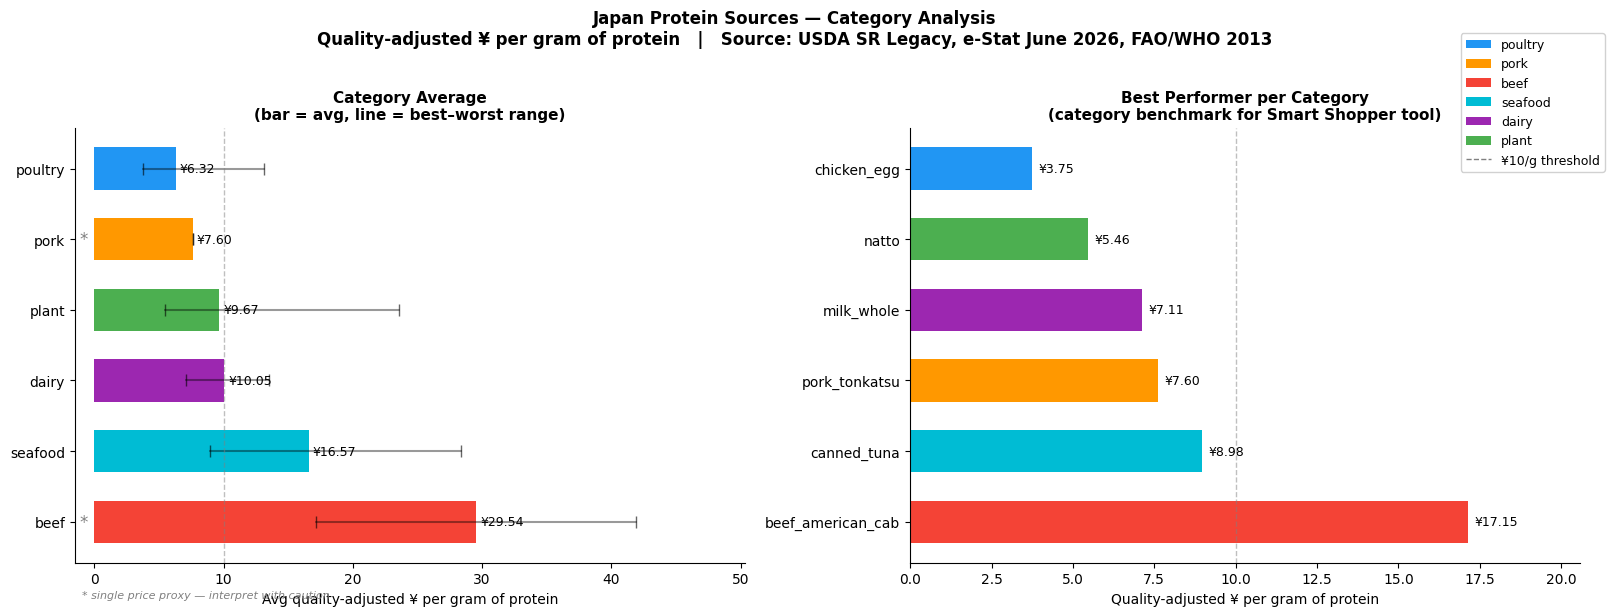

Chart saved ✓


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Average adjusted cost by category ---
ax1 = axes[0]
cat_plot = cat_summary.sort_values('avg_adjusted', ascending=False)
colors = [CAT_COLORS[c] for c in cat_plot.index]

bars = ax1.barh(cat_plot.index, cat_plot['avg_adjusted'], color=colors, edgecolor='none', height=0.6)

# Error-style range bars (best to worst within category)
for i, (cat, row) in enumerate(cat_plot.iterrows()):
    ax1.plot(
        [row['best_adjusted'], row['worst_adjusted']],
        [i, i],
        color='black', linewidth=1.5, alpha=0.4, solid_capstyle='round'
    )
    ax1.plot(row['best_adjusted'],  i, '|', color='black', markersize=8, alpha=0.6)
    ax1.plot(row['worst_adjusted'], i, '|', color='black', markersize=8, alpha=0.6)

# Value labels
for bar, val in zip(bars, cat_plot['avg_adjusted']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'¥{val:.2f}', va='center', fontsize=9)

# Asterisk on pork and beef
for i, cat in enumerate(cat_plot.index):
    if cat in ['pork', 'beef']:
        ax1.text(-0.8, i, '*', fontsize=12, color='gray', va='center', ha='center')

ax1.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Avg quality-adjusted ¥ per gram of protein', fontsize=10)
ax1.set_title('Category Average\n(bar = avg, line = best–worst range)', fontsize=11, fontweight='bold')
ax1.set_xlim(-1.5, cat_plot['worst_adjusted'].max() * 1.2)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=10)
ax1.text(0.01, -0.08, '* single price proxy — interpret with caution',
         transform=ax1.transAxes, fontsize=8, color='gray', style='italic')

# --- Panel 2: Best in category (category winner) ---
ax2 = axes[1]
best_in_cat = df.loc[df.groupby('source_category')['adjusted_yen_per_g'].idxmin()].copy()
best_in_cat = best_in_cat.sort_values('adjusted_yen_per_g', ascending=False)
colors2 = [CAT_COLORS[c] for c in best_in_cat['source_category']]

bars2 = ax2.barh(
    best_in_cat['food_key'],
    best_in_cat['adjusted_yen_per_g'],
    color=colors2, edgecolor='none', height=0.6
)

for bar, val, cat in zip(bars2, best_in_cat['adjusted_yen_per_g'], best_in_cat['source_category']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'¥{val:.2f}', va='center', fontsize=9)

ax2.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Quality-adjusted ¥ per gram of protein', fontsize=10)
ax2.set_title('Best Performer per Category\n(category benchmark for Smart Shopper tool)',
              fontsize=11, fontweight='bold')
ax2.set_xlim(0, best_in_cat['adjusted_yen_per_g'].max() * 1.2)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=10)

# Shared legend
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='¥10/g threshold'))
fig.legend(handles=legend_elements, loc='upper right', fontsize=9,
           framealpha=0.9, bbox_to_anchor=(1.01, 0.99))

fig.suptitle(
    'Japan Protein Sources — Category Analysis\n'
    'Quality-adjusted ¥ per gram of protein   |   Source: USDA SR Legacy, e-Stat June 2026, FAO/WHO 2013',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()

os.makedirs('/content/charts', exist_ok=True)
LOCAL_CHART = '/content/charts/category_analysis.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

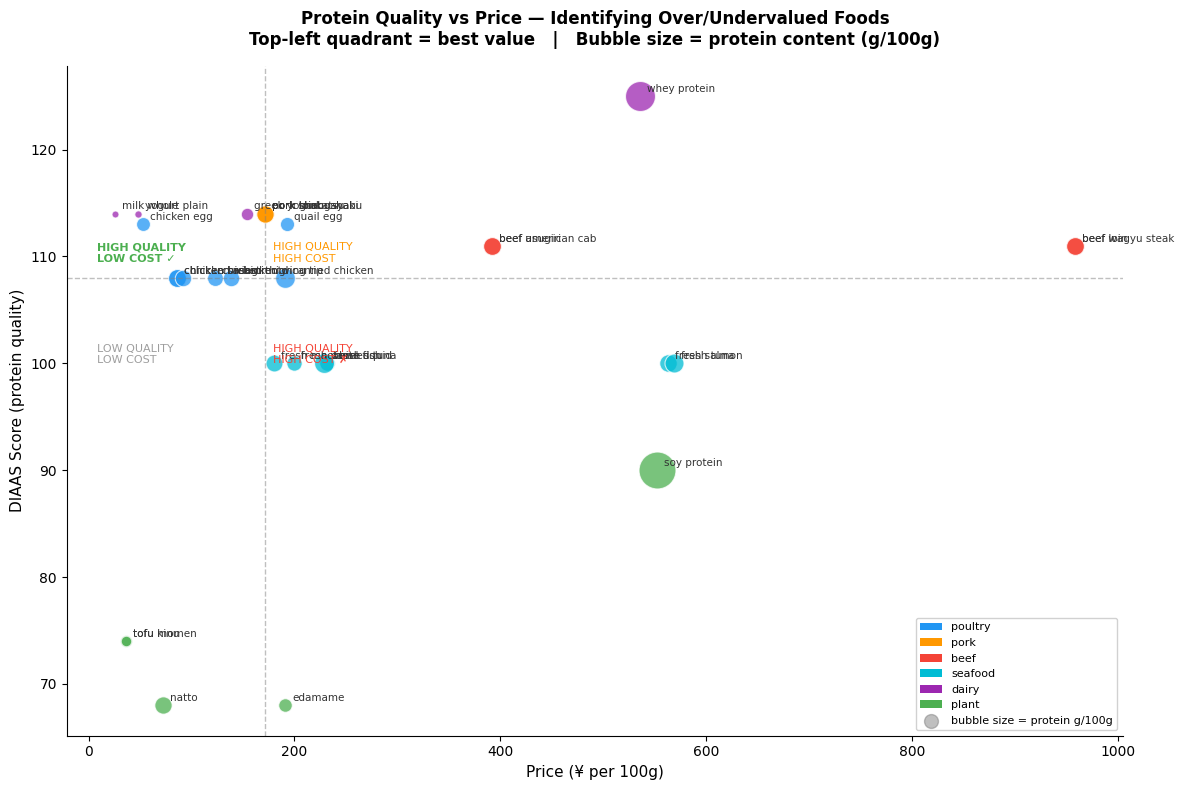

Chart saved ✓


In [ ]:
# ============================================================
# PART A — SECTION 2: PROTEIN QUALITY VS COST SCATTER PLOT
# Identifying over/undervalued foods
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

for _, row in df.iterrows():
    color = CAT_COLORS.get(row['source_category'], 'gray')
    ax.scatter(
        row['price_jpy_per_100g'],
        row['diaas_score'],
        s=row['protein_g'] * 8,  # bubble size = protein content
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.8
    )
    ax.annotate(
        row['food_key'].replace('_', ' '),
        xy=(row['price_jpy_per_100g'], row['diaas_score']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=7.5, color='#333333'
    )

# Quadrant lines
median_price = df['price_jpy_per_100g'].median()
median_diaas = df['diaas_score'].median()
ax.axvline(x=median_price, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=median_diaas, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant labels
ax.text(median_price * 0.05, median_diaas + 1.5,  'HIGH QUALITY\nLOW COST ✓',  fontsize=8, color='#4CAF50', fontweight='bold')
ax.text(median_price * 1.05, median_diaas + 1.5,  'HIGH QUALITY\nHIGH COST',   fontsize=8, color='#FF9800')
ax.text(median_price * 0.05, median_diaas - 8,    'LOW QUALITY\nLOW COST',     fontsize=8, color='#9E9E9E')
ax.text(median_price * 1.05, median_diaas - 8,    'HIGH QUALITY\nHIGH COST ✗', fontsize=8, color='#F44336')

# Legend — category colors
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
legend_elements.append(
    ax.scatter([], [], s=100, color='gray', alpha=0.5, label='bubble size = protein g/100g')
)
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.9, loc='lower right')

ax.set_xlabel('Price (¥ per 100g)', fontsize=11)
ax.set_ylabel('DIAAS Score (protein quality)', fontsize=11)
ax.set_title(
    'Protein Quality vs Price — Identifying Over/Undervalued Foods\n'
    'Top-left quadrant = best value   |   Bubble size = protein content (g/100g)',
    fontsize=12, fontweight='bold', pad=15
)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

LOCAL_CHART = '/content/charts/quality_vs_cost_scatter.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

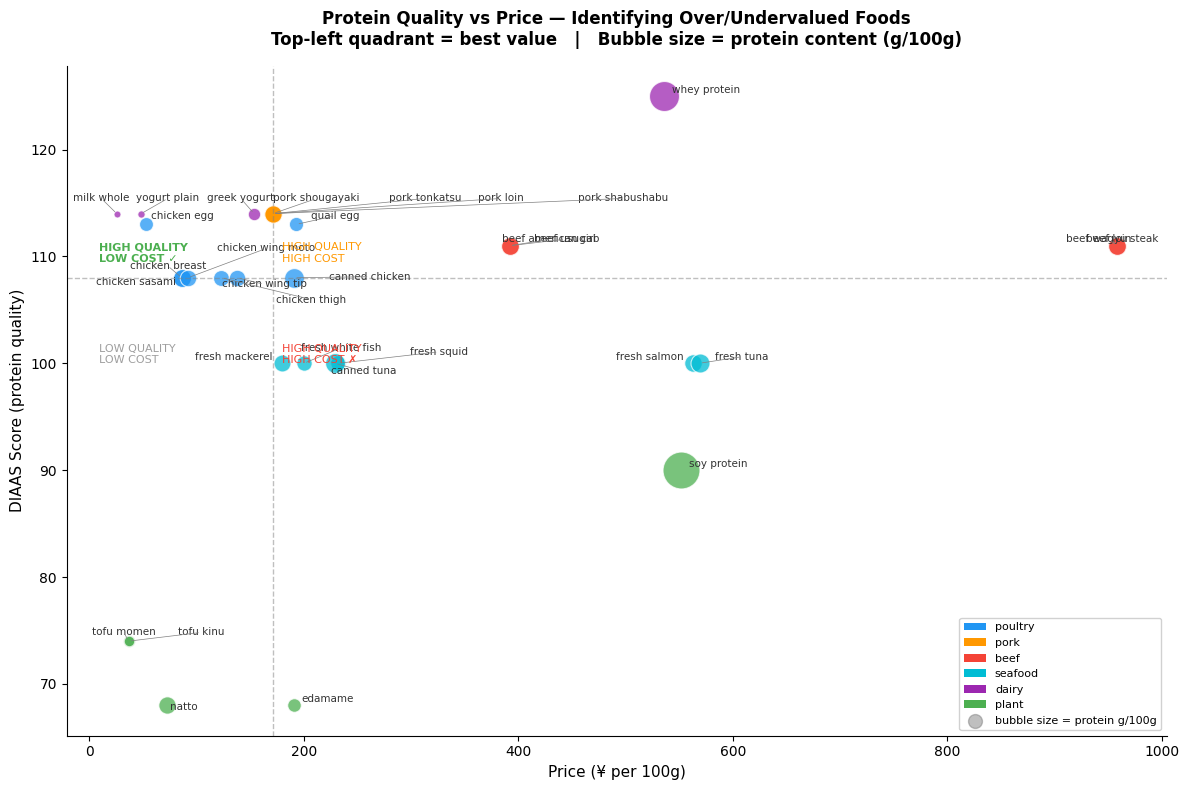

Chart saved ✓


In [ ]:
# Install adjustText if not already installed
!pip install adjustText --quiet

from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 8))

texts = []
for _, row in df.iterrows():
    color = CAT_COLORS.get(row['source_category'], 'gray')
    ax.scatter(
        row['price_jpy_per_100g'],
        row['diaas_score'],
        s=row['protein_g'] * 8,
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.8
    )
    texts.append(ax.text(
        row['price_jpy_per_100g'],
        row['diaas_score'],
        row['food_key'].replace('_', ' '),
        fontsize=7.5, color='#333333'
    ))

adjust_text(texts, ax=ax, force_text=(5.5, 5.0), force_points=(0.5, 1.0), expand_text=(1.2, 1.4), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Quadrant lines
median_price = df['price_jpy_per_100g'].median()
median_diaas = df['diaas_score'].median()
ax.axvline(x=median_price, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=median_diaas, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant labels
ax.text(median_price * 0.05, median_diaas + 1.5,  'HIGH QUALITY\nLOW COST ✓',  fontsize=8, color='#4CAF50', fontweight='bold')
ax.text(median_price * 1.05, median_diaas + 1.5,  'HIGH QUALITY\nHIGH COST',   fontsize=8, color='#FF9800')
ax.text(median_price * 0.05, median_diaas - 8,    'LOW QUALITY\nLOW COST',     fontsize=8, color='#9E9E9E')
ax.text(median_price * 1.05, median_diaas - 8,    'HIGH QUALITY\nHIGH COST ✗', fontsize=8, color='#F44336')

legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
legend_elements.append(
    ax.scatter([], [], s=100, color='gray', alpha=0.5, label='bubble size = protein g/100g')
)
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.9, loc='lower right')

ax.set_xlabel('Price (¥ per 100g)', fontsize=11)
ax.set_ylabel('DIAAS Score (protein quality)', fontsize=11)
ax.set_title(
    'Protein Quality vs Price — Identifying Over/Undervalued Foods\n'
    'Top-left quadrant = best value   |   Bubble size = protein content (g/100g)',
    fontsize=12, fontweight='bold', pad=15
)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

LOCAL_CHART = '/content/charts/quality_vs_cost_scatter.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# PART A — SECTION 3: SENSITIVITY ANALYSIS
# Vary each food's price independently, hold all others fixed
# Shows: how much does THIS food's rank improve on sale?
# ============================================================

scenarios = {
    '-30%': 0.70,
    '-20%': 0.80,
    '-10%': 0.90,
    'current': 1.00,
    '+10%': 1.10,
    '+20%': 1.20,
    '+30%': 1.30,
}

sensitivity_rows = []

for target_key in df['food_key']:
    for label, multiplier in scenarios.items():
        # Build a temporary df with only the target food's price changed
        temp_df = df.copy()
        temp_df.loc[temp_df['food_key'] == target_key, 'price_jpy_per_100g'] *= multiplier

        # Recalculate adjusted score for all foods
        temp_df['adj_yen_per_g'] = (
            temp_df['price_jpy_per_100g'] / temp_df['protein_g'] / (temp_df['diaas_score'] / 100)
        )

        # Get rank of target food in this scenario
        temp_df['rank'] = temp_df['adj_yen_per_g'].rank().astype(int)
        target_rank = temp_df.loc[temp_df['food_key'] == target_key, 'rank'].values[0]
        target_price = temp_df.loc[temp_df['food_key'] == target_key, 'price_jpy_per_100g'].values[0]
        target_adj = temp_df.loc[temp_df['food_key'] == target_key, 'adj_yen_per_g'].values[0]

        sensitivity_rows.append({
            'food_key':        target_key,
            'source_category': df.loc[df['food_key'] == target_key, 'source_category'].values[0],
            'scenario':        label,
            'price_per_100g':  round(target_price, 1),
            'adj_yen_per_g':   round(target_adj, 2),
            'rank':            target_rank,
        })

sens_df = pd.DataFrame(sensitivity_rows)

# Pivot rank by scenario
rank_pivot = sens_df.pivot_table(
    index='food_key', columns='scenario', values='rank'
)[list(scenarios.keys())]

rank_pivot['current_¥/g'] = df.set_index('food_key')['adjusted_yen_per_g']
rank_pivot['rank_swing']  = rank_pivot['-30%'].astype(int).rsub(rank_pivot['+30%'].astype(int))
rank_pivot = rank_pivot.sort_values('current')

print('=== Rank Sensitivity to Price Changes (one food at a time) ===')
print('Shows rank of each food as ITS price changes, all others held fixed')
print('rank_swing = rank at +30% minus rank at -30% (higher = more sensitive to price)\n')
print(rank_pivot.to_string())

=== Rank Sensitivity to Price Changes (one food at a time) ===
Shows rank of each food as ITS price changes, all others held fixed
rank_swing = rank at +30% minus rank at -30% (higher = more sensitive to price)

scenario           -30%  -20%  -10%  current  +10%  +20%  +30%  current_¥/g  rank_swing
food_key                                                                               
chicken_egg        1.00  1.00  1.00     1.00  3.00  3.00  4.00         3.75           3
chicken_breast     1.00  1.00  1.00     2.00  3.00  3.00  4.00         3.82           3
chicken_sasami     1.00  1.00  1.00     2.00  3.00  3.00  4.00         3.82           3
chicken_wing_moto  1.00  4.00  4.00     4.00  4.00  6.00  6.00         4.85           5
natto              2.00  4.00  5.00     5.00  6.00  6.00 10.00         5.46           8
tofu_momen         4.00  4.00  5.00     6.00  6.00  6.00 11.00         5.47           7
tofu_kinu          4.00  7.00  7.00     7.00 13.00 17.00 17.00         6.89         

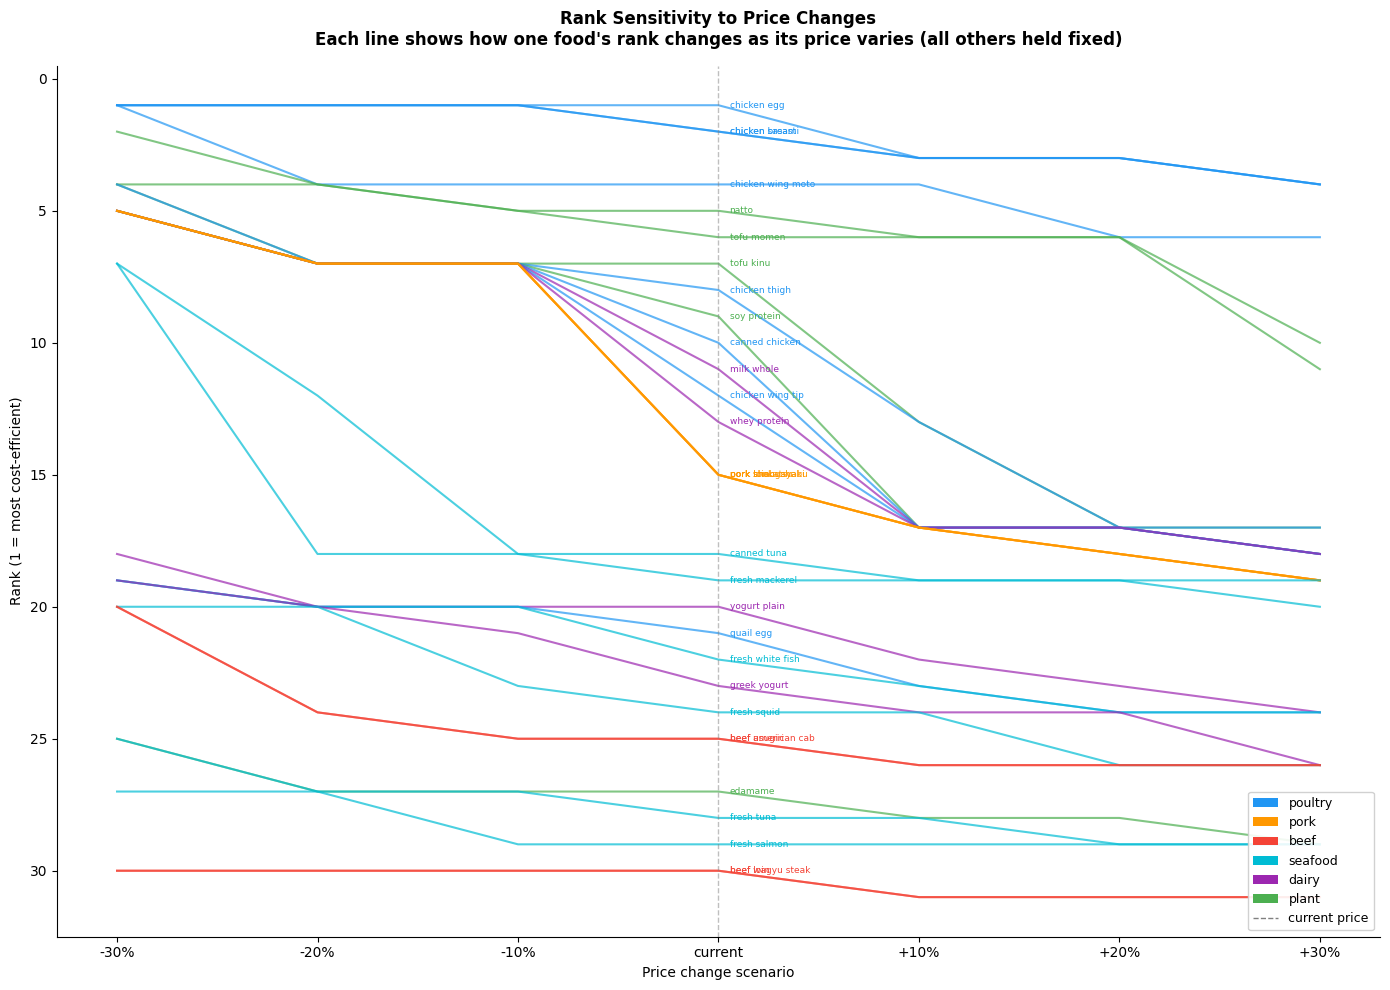

Chart saved ✓


In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(14, 10))

scenario_labels = ['-30%', '-20%', '-10%', 'current', '+10%', '+20%', '+30%']
x = np.arange(len(scenario_labels))

# Color by source_category
cat_colors = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

# Sort foods by current rank for legend ordering
foods_sorted = rank_pivot.sort_values('current').index.tolist()

for food_key in foods_sorted:
    cat = df.loc[df['food_key'] == food_key, 'source_category'].values[0]
    color = cat_colors.get(cat, 'gray')
    ranks = rank_pivot.loc[food_key, scenario_labels].values.astype(float)

    ax.plot(x, ranks, color=color, linewidth=1.5, alpha=0.7)
    # Label at current price (index 3)
    ax.annotate(
        food_key.replace('_', ' '),
        xy=(3, ranks[3]),
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=6.5, color=color, va='center'
    )

# Invert y axis — rank 1 at top
ax.invert_yaxis()
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.set_ylabel('Rank (1 = most cost-efficient)', fontsize=10)
ax.set_xlabel('Price change scenario', fontsize=10)
ax.set_title(
    'Rank Sensitivity to Price Changes\n'
    'Each line shows how one food\'s rank changes as its price varies (all others held fixed)',
    fontsize=12, fontweight='bold', pad=15
)
ax.axvline(x=3, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='current price')
ax.spines[['top', 'right']].set_visible(False)

# Category legend
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='current price'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()

LOCAL_CHART = '/content/charts/sensitivity_analysis.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# DATA CONSOLIDATION
# Remove duplicate entries sharing identical price + DIAAS
# These add noise without analytical value
# All cuts within a group are represented by the retained entry
# ============================================================

# Pork — keep pork_loin, drop 3 duplicate cuts
PORK_DUPLICATES = ['pork_tonkatsu', 'pork_shougayaki', 'pork_shabushabu']

# Beef — keep one per price point:
# beef_american_cab represents imported beef (+ beef_usugiri)
# beef_wagyu_steak represents domestic beef (+ beef_loin)
BEEF_DUPLICATES = ['beef_usugiri', 'beef_loin']

# Chicken — sasami shares identical fdc_id, price, and DIAAS with breast
CHICKEN_DUPLICATES = ['chicken_sasami']

DROP_LIST = PORK_DUPLICATES + BEEF_DUPLICATES + CHICKEN_DUPLICATES

df = df[~df['food_key'].isin(DROP_LIST)].copy().reset_index(drop=True)

# Update notes to reflect consolidation
df.loc[df['food_key'] == 'pork_loin', 'notes'] = \
    'represents all common loin cuts: tonkatsu, shougayaki, shabushabu — e-Stat imported pork proxy'
df.loc[df['food_key'] == 'beef_american_cab', 'notes'] = \
    'represents imported beef cuts incl. usugiri — e-Stat imported beef proxy'
df.loc[df['food_key'] == 'beef_wagyu_steak', 'notes'] = \
    'represents domestic beef incl. loin — e-Stat domestic beef proxy; actual wagyu likely higher'
df.loc[df['food_key'] == 'chicken_breast', 'notes'] = \
    'represents chicken breast and sasami — identical price and USDA proxy at this market'

print(f'Dataset: {len(df)} foods after consolidation (removed {len(DROP_LIST)} duplicates)')
print(f'\nRemoved: {DROP_LIST}')
print(f'\nRemaining by category:')
print(df.groupby('source_category')['food_key'].apply(list).to_string())

Dataset: 25 foods after consolidation (removed 6 duplicates)

Removed: ['pork_tonkatsu', 'pork_shougayaki', 'pork_shabushabu', 'beef_usugiri', 'beef_loin', 'chicken_sasami']

Remaining by category:
source_category
beef                             [beef_american_cab, beef_wagyu_steak]
dairy           [milk_whole, yogurt_plain, greek_yogurt, whey_protein]
plant             [natto, tofu_momen, tofu_kinu, soy_protein, edamame]
pork                                                       [pork_loin]
poultry    [chicken_breast, chicken_thigh, chicken_wing_tip, chicke...
seafood    [fresh_salmon, fresh_mackerel, fresh_squid, fresh_white_...


In [ ]:
# ============================================================
# PART B — SMART SHOPPER: BREAK-EVEN PRICE CALCULATOR
# ============================================================

df_ranked = df.sort_values('adjusted_yen_per_g').reset_index(drop=True)
df_ranked['overall_rank'] = df_ranked.index + 1
df_ranked['cat_rank'] = df_ranked.groupby('source_category')['adjusted_yen_per_g'].rank().astype(int)

overall_best = df_ranked.iloc[0]

def calc_threshold(target_row, benchmark_adj_yen):
    if benchmark_adj_yen is None:
        return None
    if target_row['adjusted_yen_per_g'] <= benchmark_adj_yen:
        return 'already beats'
    threshold = benchmark_adj_yen * (target_row['diaas_score'] / 100) * target_row['protein_g']
    return round(threshold, 1)

results = []  # defined once before loop

for idx in range(len(df_ranked)):
    row        = df_ranked.iloc[idx]
    overall_rank = row['overall_rank']
    cat          = row['source_category']
    cat_rank     = row['cat_rank']
    cat_df       = df_ranked[df_ranked['source_category'] == cat].sort_values('cat_rank').copy()

    # --- Threshold 1: Beat next overall ---
    if overall_rank == 1:
        t1, t1_ref = 'N/A — #1 overall', None
    else:
        next_overall = df_ranked[df_ranked['overall_rank'] == overall_rank - 1].iloc[0]
        t1     = calc_threshold(row, next_overall['adjusted_yen_per_g'])
        t1_ref = next_overall['food_key']

  # --- Threshold 2: Beat next in category ---
    if cat_rank == 1:
        t2, t2_ref = 'N/A — is category best', None
    elif cat_df['adjusted_yen_per_g'].nunique() == 1:
        t2, t2_ref = 'N/A — tied category', None
    else:
        better_in_cat = cat_df[cat_df['cat_rank'] < cat_rank]
        if better_in_cat.empty:
            t2, t2_ref = 'N/A — is category best', None
        else:
            next_cat = better_in_cat.iloc[-1]
            t2     = calc_threshold(row, next_cat['adjusted_yen_per_g'])
            t2_ref = next_cat['food_key']

    # --- Threshold 3: Beat category best ---
    cat_winner = cat_df.iloc[0]
    if cat_rank == 1:
        t3, t3_ref = 'N/A — is category best', None
    elif cat_df['adjusted_yen_per_g'].nunique() == 1:
        t3, t3_ref = 'N/A — tied category', None
    else:
        t3     = calc_threshold(row, cat_winner['adjusted_yen_per_g'])
        t3_ref = cat_winner['food_key']

    # --- Threshold 4: Beat overall #1 ---
    if row['food_key'] == overall_best['food_key']:
        t4, t4_ref = 'N/A — is overall #1', None
    else:
        t4     = calc_threshold(row, overall_best['adjusted_yen_per_g'])
        t4_ref = overall_best['food_key']

    results.append({
        'food_key':               row['food_key'],
        'source_category':        cat,
        'current_price_per_100g': row['price_jpy_per_100g'],
        'current_adjusted_¥/g':   row['adjusted_yen_per_g'],
        'overall_rank':           overall_rank,
        'cat_rank':               cat_rank,
        'beat_next_overall':      t1,
        'beat_next_overall_ref':  t1_ref,
        'beat_next_in_cat':       t2,
        'beat_next_in_cat_ref':   t2_ref,
        'beat_cat_winner':        t3,
        'beat_cat_winner_ref':    t3_ref,
        'beat_overall_#1':        t4,
        'beat_overall_#1_ref':    t4_ref,
    })

smart_shopper = pd.DataFrame(results)

print('=== Smart Shopper — Break-Even Price Thresholds (¥ per 100g) ===')
print('If you see a food at or below its threshold → worth buying over that benchmark\n')
print(smart_shopper[[
    'food_key', 'source_category', 'current_price_per_100g',
    'overall_rank', 'beat_next_overall', 'beat_next_in_cat',
    'beat_cat_winner', 'beat_overall_#1'
]].to_string(index=False))

=== Smart Shopper — Break-Even Price Thresholds (¥ per 100g) ===
If you see a food at or below its threshold → worth buying over that benchmark

         food_key source_category  current_price_per_100g  overall_rank beat_next_overall       beat_next_in_cat        beat_cat_winner     beat_overall_#1
      chicken_egg         poultry                   53.20             1  N/A — #1 overall N/A — is category best N/A — is category best N/A — is overall #1
   chicken_breast         poultry                   86.20             2             84.40                  84.40                  84.40               84.40
chicken_wing_moto         poultry                   91.80             3             72.30                  72.30                  71.00               71.00
            natto           plant                   72.00             4             64.00 N/A — is category best N/A — is category best               49.50
       tofu_momen           plant                   36.60             5    

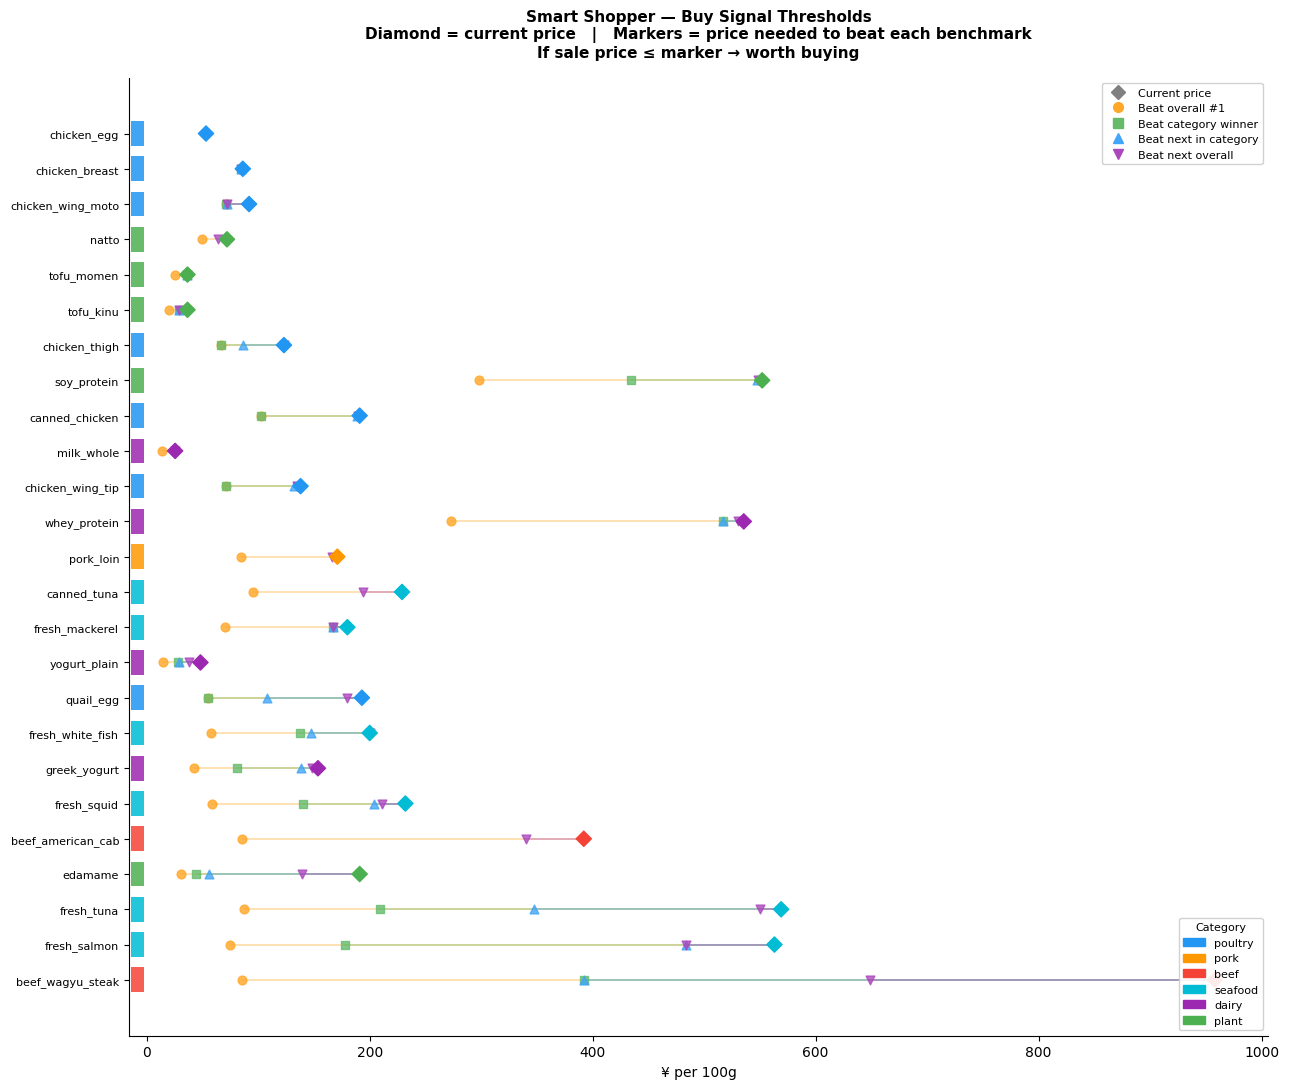

Chart saved ✓


In [ ]:
os.makedirs('/content/charts', exist_ok=True)

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

# Numeric conversion helper
def to_num(val):
    try:
        return float(val)
    except:
        return np.nan

ss = smart_shopper.copy()
for col in ['beat_next_overall', 'beat_next_in_cat', 'beat_cat_winner', 'beat_overall_#1']:
    ss[col + '_num'] = ss[col].apply(to_num)

# Sort best to worst (ascending adjusted score = best at top)
ss = ss.sort_values('overall_rank', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 11))

y = np.arange(len(ss))

# Current price markers
ax.scatter(ss['current_price_per_100g'], y,
           color=[CAT_COLORS[c] for c in ss['source_category']],
           s=60, zorder=5, label='Current price', marker='D')

# Threshold bars — horizontal lines from threshold to current price
threshold_styles = [
    ('beat_overall_#1_num',   '#FFA726', 'o', 'Beat overall #1 (egg)'),
    ('beat_cat_winner_num',   '#66BB6A', 's', 'Beat category winner'),
    ('beat_next_in_cat_num',  '#42A5F5', '^', 'Beat next in category'),
    ('beat_next_overall_num', '#AB47BC', 'v', 'Beat next overall'),
]

for col, color, marker, label in threshold_styles:
    valid = ss[ss[col + ''].notna() if col in ss.columns else ss[col].notna()]
    # Plot threshold markers
    ax.scatter(ss[col], y, color=color, s=40, marker=marker,
               alpha=0.8, zorder=4, label=label)
    # Draw line from threshold to current price
    for i, row in ss.iterrows():
        threshold = row[col]
        current   = row['current_price_per_100g']
        if not np.isnan(threshold) and threshold < current:
            ax.plot([threshold, current], [i, i],
                    color=color, linewidth=1.2, alpha=0.4)

# Food labels on y axis
ax.set_yticks(y)
ax.set_yticklabels(ss['food_key'], fontsize=8)

# Category color stripe
for i, row in ss.iterrows():
    ax.barh(i, 12, 0.7, left=-14,
            color=CAT_COLORS.get(row['source_category'], 'gray'),
            edgecolor='none', alpha=0.85)

ax.set_xlabel('¥ per 100g', fontsize=10)
ax.set_xlim(-16, ss['current_price_per_100g'].max() * 1.05)
ax.set_title(
    'Smart Shopper — Buy Signal Thresholds\n'
    'Diamond = current price   |   Markers = price needed to beat each benchmark\n'
    'If sale price ≤ marker → worth buying',
    fontsize=11, fontweight='bold', pad=15
)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

# Legends
cat_patches = [mpatches.Patch(color=c, label=cat) for cat, c in CAT_COLORS.items()]
threshold_patches = [
    plt.Line2D([0],[0], marker='D', color='gray', markersize=7, linestyle='None', label='Current price'),
    plt.Line2D([0],[0], marker='o', color='#FFA726', markersize=7, linestyle='None', label='Beat overall #1'),
    plt.Line2D([0],[0], marker='s', color='#66BB6A', markersize=7, linestyle='None', label='Beat category winner'),
    plt.Line2D([0],[0], marker='^', color='#42A5F5', markersize=7, linestyle='None', label='Beat next in category'),
    plt.Line2D([0],[0], marker='v', color='#AB47BC', markersize=7, linestyle='None', label='Beat next overall'),
]

leg1 = ax.legend(handles=cat_patches, loc='lower right', fontsize=8,
                 framealpha=0.9, title='Category', title_fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=threshold_patches, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()

LOCAL_CHART = '/content/charts/smart_shopper_thresholds.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

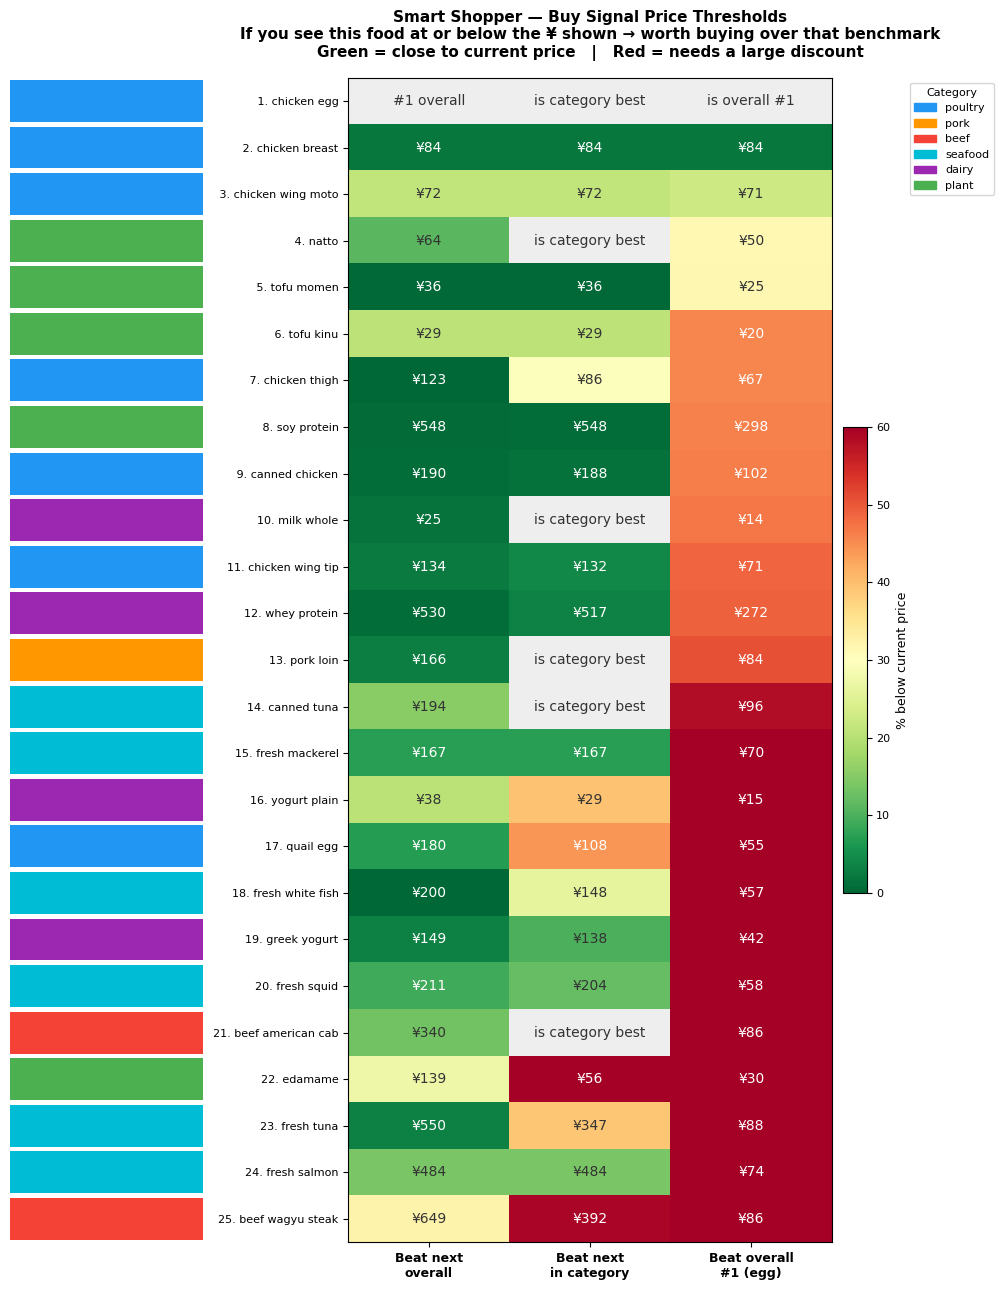

Chart saved ✓


In [ ]:
import matplotlib.colors as mcolors

ss_plot = smart_shopper.sort_values('overall_rank').copy()

# Build numeric threshold matrix
cols = {
    'Beat next\noverall':     'beat_next_overall',
    'Beat next\nin category': 'beat_next_in_cat',
    'Beat overall\n#1 (egg)': 'beat_overall_#1',
}

matrix = []
labels = []
for _, row in ss_plot.iterrows():
    food_row = []
    label_row = []
    current = row['current_price_per_100g']
    for col_label, col in cols.items():
        val = to_num(row[col])
        if np.isnan(val):
            food_row.append(np.nan)
            label_row.append(str(row[col]).replace('N/A — ', '').replace('already beats', '✓ already'))
        else:
            # Pct drop needed
            pct_drop = (current - val) / current * 100
            food_row.append(pct_drop)
            label_row.append(f'¥{val:.0f}')
    matrix.append(food_row)
    labels.append(label_row)

matrix = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(12, 13))

# Color: green = small drop needed, red = large drop needed, gray = N/A
cmap = plt.cm.RdYlGn_r
cmap.set_bad(color='#EEEEEE')

im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=60, aspect='auto')

# Cell text
for i in range(len(ss_plot)):
    for j in range(len(cols)):
        text = labels[i][j]
        val = matrix[i][j]
        color = 'white' if (not np.isnan(val) and (val > 40 or val < 10)) else '#333333'
        ax.text(j, i, text, ha='center', va='center',
                fontsize=10, color=color, linespacing=1.4)

# Axes
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols.keys(), fontsize=9, fontweight='bold')
ax.set_yticks(range(len(ss_plot)))
ax.set_yticklabels(
    [f"{int(r['overall_rank']):2d}. {r['food_key'].replace('_',' ')}"
     for _, r in ss_plot.iterrows()],
    fontsize=8
)

# Category color bar on left
for i, (_, row) in enumerate(ss_plot.iterrows()):
    ax.barh(i, 0.4, 0.9, left=-0.7,
            color=CAT_COLORS.get(row['source_category'], 'gray'),
            transform=ax.get_yaxis_transform(), clip_on=False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('% below current price', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title(
    'Smart Shopper — Buy Signal Price Thresholds\n'
    'If you see this food at or below the ¥ shown → worth buying over that benchmark\n'
    'Green = close to current price   |   Red = needs a large discount',
    fontsize=11, fontweight='bold', pad=15
)

# Category legend
cat_patches = [mpatches.Patch(color=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=cat_patches, bbox_to_anchor=(1.15, 1), loc='upper left',
          fontsize=8, title='Category', title_fontsize=8)

plt.tight_layout()

LOCAL_CHART = '/content/charts/smart_shopper_heatmap.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

### Smart Shopper — Buy Signal Thresholds

**Answers the question:** "If this food goes on sale, at what price does it become a better protein deal than the next cheapest option?"


**What is the ranking?**
Foods are ranked by **quality-adjusted cost efficiency**: ¥ per gram of protein, adjusted for protein quality (DIAAS score).

adjusted_yen_per_g = (price_jpy_per_100g / protein_g) / (diaas_score / 100)

Rank 1 (chicken egg) = most cost-efficient gram of usable protein in Japan.

**How to read the heatmap:**
Each cell shows the **maximum price per 100g** you should pay for that food to beat a given benchmark. The color shows how achievable that discount is:
- 🟢 **Green** — close to current price, achievable on a normal sale
- 🔴 **Red** — requires a large discount to beat the benchmark
- ⬜ **Gray** — N/A (already beats, tied category, or is the benchmark itself)

**Three benchmarks:**
- **Beat next overall** — overtake the food ranked directly above in the full ranking
- **Beat next in category** — overtake the food ranked directly above within its category
- **Beat overall #1** — beat chicken egg (¥3.75/g adjusted protein) — the gold standard

## Muscle Cost Efficiency — Composite Score Design

### Proposed weights: Leucine 50% / BCAA 30% / DIAAS 20%

### Rationale

**Leucine 50%**
Norton & Layman (2006) and Churchward-Venne et al. (2012) establish leucine as the primary signal for mTORC1 activation and MPS initiation. It is the single most studied and most cited amino acid in muscle building research. Highest weight justified.

**BCAA 30%**
Isoleucine and valine work synergistically with leucine to sustain MPS and support energy metabolism during resistance training (Shimomura et al., 2006). Important but secondary to leucine alone.

**DIAAS 20%**
Captures overall protein digestibility and completeness across all IAAs. Ensures the score penalizes low-quality proteins even if they have adequate leucine. Lower weight because leucine and BCAA already capture much of the muscle-relevant AA quality.

---

### Sensitivity check

We'll test 3 weight sets:

| Label | Leucine | BCAA | DIAAS |
|---|---|---|---|
| Conservative | 40% | 40% | 20% |
| Base case | 50% | 30% | 20% |
| Leucine-heavy | 60% | 25% | 15% |

If top 5 foods stay consistent across all three → composite is robust.

In [ ]:
# ============================================================
# MUSCLE COST EFFICIENCY COMPOSITE SCORE
# Combines leucine, BCAA, and DIAAS into a single metric
#
# Weights rationale (literature-based):
# Leucine 50% — primary MPS trigger via mTORC1 activation
#               (Norton & Layman, 2006; Churchward-Venne et al., 2012)
# BCAA    30% — synergistic role of Ile+Val in sustaining MPS
#               and energy metabolism (Shimomura et al., 2006)
# DIAAS   20% — overall protein digestibility and IAA completeness
#               (FAO/WHO, 2013)
#
# Formula:
# muscle_score = (leucine × 0.50) + (total_bcaa × 0.30) + (diaas/100 × 0.20)
# muscle_cost  = price_jpy_per_100g / muscle_score
# Lower muscle_cost = better muscle value per yen
# ============================================================

# Load aa_merged from Drive
results = service.files().list(
    q=f"name='aa_merged.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

file_id = results['files'][0]['id']
request = service.files().get_media(fileId=file_id)
fh = io.BytesIO()
downloader = MediaIoBaseDownload(fh, request)
done = False
while not done:
    _, done = downloader.next_chunk()
fh.seek(0)
aa = pd.read_csv(fh)

# Filter to consolidated 25 foods
aa = aa[~aa['food_key'].isin(DROP_LIST)].copy().reset_index(drop=True)
print(f'aa_merged loaded: {aa.shape[0]} foods')

# Merge with df to get current prices
aa_costs = aa[['food_key', 'leucine', 'total_bcaa_g', 'diaas_score',
               'price_jpy_per_100g', 'source_category']].copy()

# ============================================================
# WEIGHT SENSITIVITY ANALYSIS — Option C
# ============================================================
WEIGHT_SETS = {
    'Conservative (40/40/20)':   (0.40, 0.40, 0.20),
    'Base case (50/30/20)':      (0.50, 0.30, 0.20),
    'Leucine-heavy (60/25/15)':  (0.60, 0.25, 0.15),
}

sensitivity_results = {}

for label, (w_leu, w_bcaa, w_diaas) in WEIGHT_SETS.items():
    aa_costs[f'muscle_score'] = (
        aa_costs['leucine']       * w_leu +
        aa_costs['total_bcaa_g'] * w_bcaa +
        (aa_costs['diaas_score'] / 100) * w_diaas
    )
    aa_costs[f'muscle_cost'] = (
        aa_costs['price_jpy_per_100g'] / aa_costs['muscle_score']
    ).round(2)
    aa_costs[f'muscle_rank'] = aa_costs['muscle_cost'].rank().astype(int)
    sensitivity_results[label] = aa_costs[['food_key', 'muscle_cost', 'muscle_rank']].copy()

# Build sensitivity pivot
rank_pivot = pd.DataFrame({'food_key': aa_costs['food_key']})
for label, res in sensitivity_results.items():
    rank_pivot = rank_pivot.merge(
        res[['food_key', 'muscle_rank']].rename(columns={'muscle_rank': label}),
        on='food_key'
    )

# Add base case score for sorting
rank_pivot['base_rank'] = rank_pivot['Base case (50/30/20)']
rank_pivot = rank_pivot.sort_values('base_rank')

print('\n=== Muscle Cost Efficiency — Weight Sensitivity Analysis ===')
print('Rank 1 = best muscle value per yen\n')
print(rank_pivot.drop(columns='base_rank').to_string(index=False))

# Check top 5 consistency
print('\n=== Top 5 Consistency Check ===')
for label in WEIGHT_SETS.keys():
    top5 = rank_pivot.nsmallest(5, label)['food_key'].tolist()
    print(f'{label}: {top5}')

aa_merged loaded: 25 foods

=== Muscle Cost Efficiency — Weight Sensitivity Analysis ===
Rank 1 = best muscle value per yen

         food_key  Conservative (40/40/20)  Base case (50/30/20)  Leucine-heavy (60/25/15)
      chicken_egg                        1                     1                         1
       tofu_momen                        2                     2                         2
            natto                        3                     3                         3
   chicken_breast                        4                     4                         4
       milk_whole                        5                     5                         5
chicken_wing_moto                        6                     6                         6
        tofu_kinu                        7                     7                         7
      soy_protein                        8                     8                         8
     whey_protein                        9              

In [ ]:
# Check if leucine and BCAA rankings are already identical
aa_costs['leucine_rank'] = aa_costs['leucine'].rank().astype(int)
aa_costs['bcaa_rank']    = aa_costs['total_bcaa_g'].rank().astype(int)
aa_costs['diaas_rank']   = aa_costs['diaas_score'].rank().astype(int)
aa_costs['price_rank']   = aa_costs['price_jpy_per_100g'].rank().astype(int)

print('=== Individual metric rankings ===')
print(aa_costs.sort_values('leucine_rank')[[
    'food_key', 'leucine_rank', 'bcaa_rank', 'diaas_rank', 'price_rank'
]].to_string(index=False))

# Correlation between rankings
from scipy.stats import spearmanr
leu_bcaa, _ = spearmanr(aa_costs['leucine_rank'], aa_costs['bcaa_rank'])
leu_diaas, _ = spearmanr(aa_costs['leucine_rank'], aa_costs['diaas_rank'])
print(f'\nSpearman correlation:')
print(f'  Leucine vs BCAA rank:  {leu_bcaa:.3f}')
print(f'  Leucine vs DIAAS rank: {leu_diaas:.3f}')

=== Individual metric rankings ===
         food_key  leucine_rank  bcaa_rank  diaas_rank  price_rank
       milk_whole             1          1          22           1
     yogurt_plain             2          2          22           4
        tofu_kinu             3          3           3           2
     greek_yogurt             4          4          22          11
       tofu_momen             5          6           3           2
          edamame             6          5           1          14
      chicken_egg             7          8          19           5
      fresh_squid             8          7           8          19
        quail_egg             9         11          19          16
 fresh_white_fish            10          8           8          17
    chicken_thigh            11         10          14           9
chicken_wing_moto            12         12          14           8
 chicken_wing_tip            12         12          14          10
            natto          

In [ ]:
# Verify what muscle_cost actually looks like for base case
w_leu, w_bcaa, w_diaas = 0.50, 0.30, 0.20

aa_costs['muscle_score_base'] = (
    aa_costs['leucine']          * w_leu +
    aa_costs['total_bcaa_g']     * w_bcaa +
    (aa_costs['diaas_score']/100) * w_diaas
)
aa_costs['muscle_cost_base'] = (
    aa_costs['price_jpy_per_100g'] / aa_costs['muscle_score_base']
).round(2)

print('=== Muscle Score vs Muscle Cost ===')
print(aa_costs.sort_values('muscle_cost_base')[[
    'food_key', 'price_jpy_per_100g', 'leucine',
    'total_bcaa_g', 'diaas_score',
    'muscle_score_base', 'muscle_cost_base'
]].to_string(index=False))

=== Muscle Score vs Muscle Cost ===
         food_key  price_jpy_per_100g  leucine  total_bcaa_g  diaas_score  muscle_score_base  muscle_cost_base
      chicken_egg               53.20     1.09          2.62          113               1.56             34.21
       tofu_momen               36.60     0.73          1.63           74               1.00             36.56
            natto               72.00     1.51          3.46           68               1.93             37.33
   chicken_breast               86.20     1.53          3.62          108               2.07             41.66
       milk_whole               25.50     0.30          0.67          114               0.58             44.08
chicken_wing_moto               91.80     1.45          3.22          108               1.91             48.15
        tofu_kinu               36.60     0.50          1.15           74               0.74             49.33
      soy_protein              552.00     6.78         15.13           90   

In [ ]:
# Extreme sensitivity test — what if DIAAS weight is very high?
EXTREME_WEIGHT_SETS = {
    'Leucine only (100/0/0)':      (1.00, 0.00, 0.00),
    'Base case (50/30/20)':        (0.50, 0.30, 0.20),
    'DIAAS heavy (30/20/50)':      (0.30, 0.20, 0.50),
    'DIAAS only (0/0/100)':        (0.00, 0.00, 1.00),
}

rank_pivot2 = pd.DataFrame({'food_key': aa_costs['food_key']})

for label, (w_leu, w_bcaa, w_diaas) in EXTREME_WEIGHT_SETS.items():
    aa_costs['muscle_score_test'] = (
        aa_costs['leucine']           * w_leu +
        aa_costs['total_bcaa_g']      * w_bcaa +
        (aa_costs['diaas_score']/100) * w_diaas
    )
    aa_costs['muscle_cost_test'] = (
        aa_costs['price_jpy_per_100g'] / aa_costs['muscle_score_test']
    ).round(2)
    aa_costs['muscle_rank_test'] = aa_costs['muscle_cost_test'].rank().astype(int)
    rank_pivot2 = rank_pivot2.merge(
        aa_costs[['food_key','muscle_rank_test']].rename(
            columns={'muscle_rank_test': label}),
        on='food_key'
    )

rank_pivot2 = rank_pivot2.sort_values('Base case (50/30/20)')
print('=== Extreme Weight Sensitivity ===\n')
print(rank_pivot2.to_string(index=False))

print('\n=== Top 5 per weight set ===')
for label in EXTREME_WEIGHT_SETS.keys():
    top5 = rank_pivot2.nsmallest(5, label)['food_key'].tolist()
    print(f'{label:35s}: {top5}')

=== Extreme Weight Sensitivity ===

         food_key  Leucine only (100/0/0)  Base case (50/30/20)  DIAAS heavy (30/20/50)  DIAAS only (0/0/100)
      chicken_egg                       2                     1                       2                     3
       tofu_momen                       3                     2                       3                     4
            natto                       1                     3                       4                     8
   chicken_breast                       4                     4                       6                     6
       milk_whole                       9                     5                       1                     1
chicken_wing_moto                       5                     6                       7                     7
        tofu_kinu                       6                     7                       5                     4
      soy_protein                       8                     8                     

## Revised Composite — Leucine 70% / DIAAS 30%

### Rationale

**Component selection**
BCAA (isoleucine + valine) was initially included as a secondary muscle-building metric but was removed after sensitivity analysis revealed a Spearman correlation of 0.98 between leucine rank and BCAA rank across 25 foods. Including BCAA alongside leucine adds no independent information — it is effectively a weighted duplicate of leucine. Parsimony favors removing it.

**Leucine 70%**
Leucine is the primary indispensable amino acid for mTORC1 activation and muscle protein synthesis initiation (Norton & Layman, 2006; Churchward-Venne et al., 2012). As the single most studied and most actionable amino acid for muscle building, it receives the majority weight.

**DIAAS 30%**
DIAAS (FAO/WHO, 2013) captures overall protein digestibility and completeness across all 9 indispensable amino acids. Sensitivity analysis confirmed that DIAAS weight meaningfully changes the ranking — particularly for low-cost, low-DIAAS plant proteins (natto, tofu) vs low-cost, high-DIAAS dairy proteins (milk, yogurt). A 30% weight ensures protein quality is penalized without overwhelming the leucine signal.

**Robustness**
The top 4 foods (chicken egg, tofu momen, natto, chicken breast) are consistent across all weight combinations tested, including extreme cases (leucine-only and DIAAS-only). The composite ranking is therefore robust for the top performers most relevant to consumer decision-making.

In [ ]:
# ============================================================
# MUSCLE COST EFFICIENCY COMPOSITE SCORE — FINAL
# Components: Leucine (70%) + DIAAS (30%)
#
# BCAA excluded: Spearman correlation with leucine rank = 0.98
# — adds no independent information beyond leucine content
#
# Leucine 70%: primary mTORC1 activator and MPS trigger
#              (Norton & Layman, 2006; Churchward-Venne et al., 2012)
# DIAAS   30%: overall protein digestibility and IAA completeness
#              (FAO/WHO, 2013)
#              Sensitivity analysis confirms DIAAS weight materially
#              affects ranking — justifying its inclusion
#
# Robustness: top 4 foods consistent across all weight sets tested
#
# Formula:
# muscle_score = (leucine × 0.70) + (diaas/100 × 0.30)
# muscle_cost  = price_jpy_per_100g / muscle_score
# Lower muscle_cost = better muscle value per yen
# ============================================================

W_LEU   = 0.70
W_DIAAS = 0.30

aa_costs['muscle_score_final'] = (
    aa_costs['leucine']           * W_LEU +
    (aa_costs['diaas_score']/100) * W_DIAAS
).round(3)

aa_costs['muscle_cost_final'] = (
    aa_costs['price_jpy_per_100g'] / aa_costs['muscle_score_final']
).round(2)

aa_costs['muscle_rank_final'] = aa_costs['muscle_cost_final'].rank().astype(int)

# Final sensitivity check with new weights
FINAL_SENSITIVITY = {
    'Leucine only (100/0)':   (1.00, 0.00),
    'Base case (70/30)':      (0.70, 0.30),
    'DIAAS heavy (40/60)':    (0.40, 0.60),
    'DIAAS only (0/100)':     (0.00, 1.00),
}

rank_final = pd.DataFrame({'food_key': aa_costs['food_key']})
for label, (w_leu, w_diaas) in FINAL_SENSITIVITY.items():
    aa_costs['_score_temp'] = (
        aa_costs['leucine']           * w_leu +
        (aa_costs['diaas_score']/100) * w_diaas
    )
    aa_costs['_cost_temp'] = (
        aa_costs['price_jpy_per_100g'] / aa_costs['_score_temp']
    )
    aa_costs['_rank_temp'] = aa_costs['_cost_temp'].rank().astype(int)
    rank_final = rank_final.merge(
        aa_costs[['food_key','_rank_temp']].rename(
            columns={'_rank_temp': label}),
        on='food_key'
    )

rank_final = rank_final.sort_values('Base case (70/30)')

print('=== Final Muscle Cost Efficiency Ranking ===')
print('muscle_cost = price_jpy_per_100g / (leucine×0.70 + diaas/100×0.30)\n')
print(aa_costs.sort_values('muscle_rank_final')[[
    'food_key', 'source_category', 'leucine', 'diaas_score',
    'price_jpy_per_100g', 'muscle_score_final', 'muscle_cost_final', 'muscle_rank_final'
]].to_string(index=False))

print('\n=== Final Sensitivity Check ===')
print(rank_final.to_string(index=False))

print('\n=== Top 5 per weight set ===')
for label in FINAL_SENSITIVITY.keys():
    top5 = rank_final.nsmallest(5, label)['food_key'].tolist()
    print(f'{label:25s}: {top5}')

=== Final Muscle Cost Efficiency Ranking ===
muscle_cost = price_jpy_per_100g / (leucine×0.70 + diaas/100×0.30)

         food_key source_category  leucine  diaas_score  price_jpy_per_100g  muscle_score_final  muscle_cost_final  muscle_rank_final
       milk_whole           dairy     0.30          114               25.50                0.55              46.28                  1
      chicken_egg         poultry     1.09          113               53.20                1.10              48.41                  2
       tofu_momen           plant     0.73           74               36.60                0.73              50.00                  3
            natto           plant     1.51           68               72.00                1.26              57.14                  4
   chicken_breast         poultry     1.53          108               86.20                1.40              61.66                  5
        tofu_kinu           plant     0.50           74               36.60        

In [ ]:
# ============================================================
# MUSCLE SMART SHOPPER — Break-Even Price Thresholds
# Same logic as general Smart Shopper but ranked by
# muscle_cost_final instead of adjusted_yen_per_g
# ============================================================

# Setup ranks
muscle_ranked = aa_costs.sort_values('muscle_rank_final').reset_index(drop=True)
muscle_ranked['overall_rank'] = muscle_ranked.index + 1
muscle_ranked['cat_rank'] = muscle_ranked.groupby(
    'source_category')['muscle_cost_final'].rank().astype(int)

overall_best = muscle_ranked.iloc[0]  # milk_whole

def calc_muscle_threshold(target_row, benchmark_cost):
    """
    Calculate max price_per_100g for target food to beat benchmark_cost.
    Formula: price = benchmark_cost × muscle_score_final
    """
    if benchmark_cost is None:
        return None
    if target_row['muscle_cost_final'] <= benchmark_cost:
        return 'already beats'
    threshold = benchmark_cost * target_row['muscle_score_final']
    return round(threshold, 1)

muscle_results = []
for idx in range(len(muscle_ranked)):
    row          = muscle_ranked.iloc[idx]
    overall_rank = row['overall_rank']
    cat          = row['source_category']
    cat_rank     = row['cat_rank']
    cat_df       = muscle_ranked[muscle_ranked['source_category'] == cat].sort_values('cat_rank')

    # Threshold 1: beat next overall
    if overall_rank == 1:
        t1, t1_ref = 'N/A — #1 overall', None
    else:
        next_overall = muscle_ranked[muscle_ranked['overall_rank'] == overall_rank - 1].iloc[0]
        t1     = calc_muscle_threshold(row, next_overall['muscle_cost_final'])
        t1_ref = next_overall['food_key']

    # Threshold 2: beat next in category
    if cat_rank == 1:
        t2, t2_ref = 'N/A — is category best', None
    elif cat_df['muscle_cost_final'].nunique() == 1:
        t2, t2_ref = 'N/A — tied category', None
    else:
        better_in_cat = cat_df[cat_df['cat_rank'] < cat_rank]
        if better_in_cat.empty:
            t2, t2_ref = 'N/A — is category best', None
        else:
            next_cat = better_in_cat.iloc[-1]
            t2     = calc_muscle_threshold(row, next_cat['muscle_cost_final'])
            t2_ref = next_cat['food_key']

    # Threshold 3: beat overall #1
    if row['food_key'] == overall_best['food_key']:
        t3, t3_ref = 'N/A — is overall #1', None
    else:
        t3     = calc_muscle_threshold(row, overall_best['muscle_cost_final'])
        t3_ref = overall_best['food_key']

    muscle_results.append({
        'food_key':               row['food_key'],
        'source_category':        cat,
        'current_price_per_100g': row['price_jpy_per_100g'],
        'muscle_rank':            overall_rank,
        'muscle_cost_final':      row['muscle_cost_final'],
        'beat_next_overall':      t1,
        'beat_next_in_cat':       t2,
        'beat_overall_#1':        t3,
    })

muscle_ss = pd.DataFrame(muscle_results)

print('=== Muscle Smart Shopper — Break-Even Price Thresholds ===')
print('Ranked by: muscle_cost = price / (leucine×0.70 + diaas/100×0.30)\n')
print(muscle_ss[[
    'food_key', 'source_category', 'current_price_per_100g',
    'muscle_rank', 'beat_next_overall', 'beat_next_in_cat', 'beat_overall_#1'
]].to_string(index=False))

=== Muscle Smart Shopper — Break-Even Price Thresholds ===
Ranked by: muscle_cost = price / (leucine×0.70 + diaas/100×0.30)

         food_key source_category  current_price_per_100g  muscle_rank beat_next_overall       beat_next_in_cat     beat_overall_#1
       milk_whole           dairy                   25.50            1  N/A — #1 overall N/A — is category best N/A — is overall #1
      chicken_egg         poultry                   53.20            2             50.90 N/A — is category best               50.90
       tofu_momen           plant                   36.60            3             35.40 N/A — is category best               33.90
            natto           plant                   72.00            4             63.00                  63.00               58.30
   chicken_breast         poultry                   86.20            5             79.90                  67.70               64.70
        tofu_kinu           plant                   36.60            6             

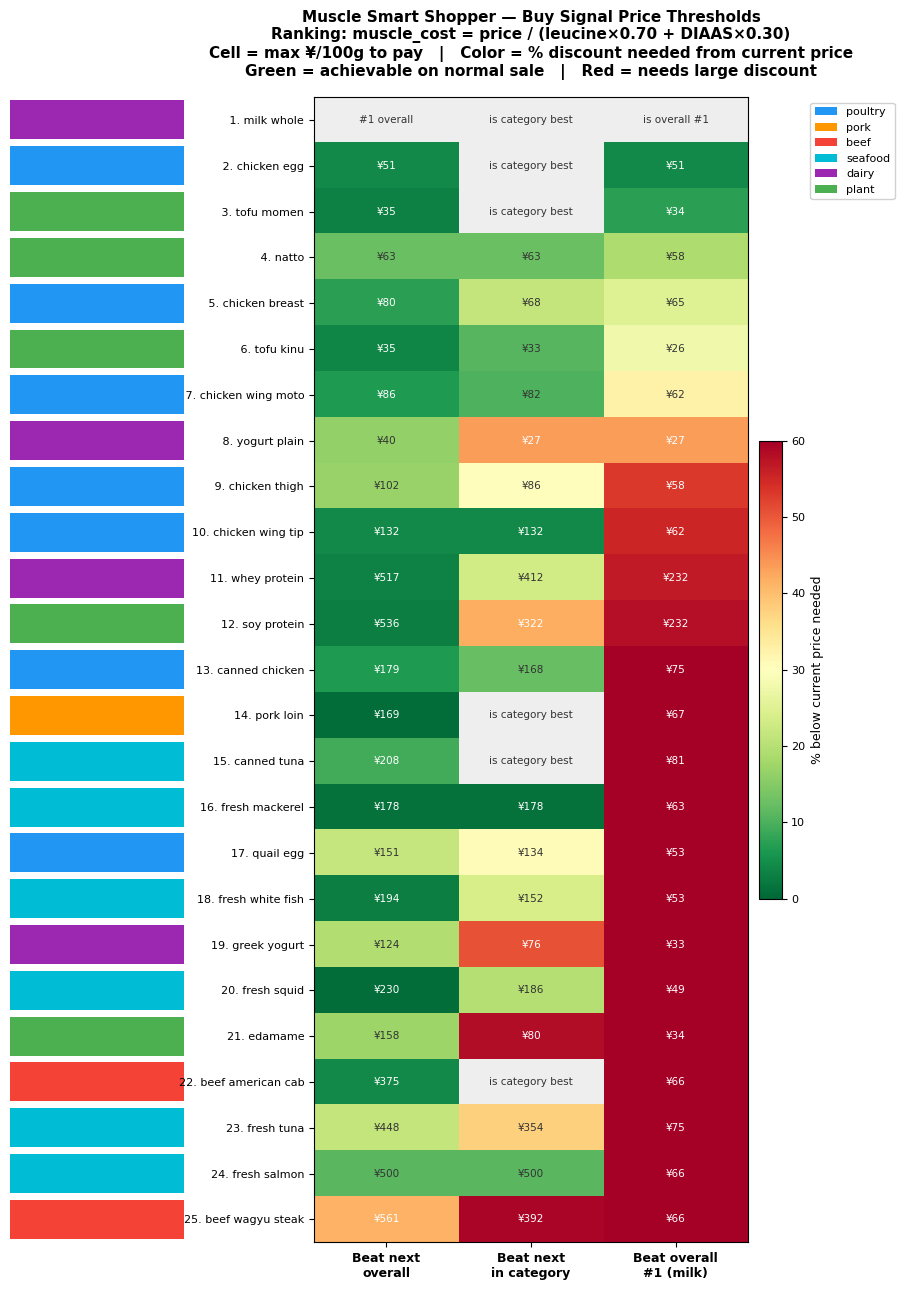

Chart saved ✓


In [ ]:
def to_num(val):
    try:
        return float(val)
    except:
        return np.nan

# Build matrix
cols = {
    'Beat next\noverall':     'beat_next_overall',
    'Beat next\nin category': 'beat_next_in_cat',
    'Beat overall\n#1 (milk)':'beat_overall_#1',
}

muscle_ss_plot = muscle_ss.sort_values('muscle_rank').copy()

matrix = []
labels = []
for _, row in muscle_ss_plot.iterrows():
    food_row  = []
    label_row = []
    current   = row['current_price_per_100g']
    for col_label, col in cols.items():
        val = to_num(row[col])
        if np.isnan(val):
            food_row.append(np.nan)
            label_row.append(
                str(row[col])
                .replace('N/A — ', '')
                .replace('already beats', '✓ already')
            )
        else:
            pct_drop = (current - val) / current * 100
            food_row.append(pct_drop)
            label_row.append(f'¥{val:.0f}')
    matrix.append(food_row)
    labels.append(label_row)

matrix = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(12, 13))

cmap = plt.cm.RdYlGn_r
cmap.set_bad(color='#EEEEEE')

im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=60, aspect='auto')

# Cell text
for i in range(len(muscle_ss_plot)):
    for j in range(len(cols)):
        text  = labels[i][j]
        val   = matrix[i][j]
        color = 'white' if (not np.isnan(val) and (val > 40 or val < 10)) else '#333333'
        ax.text(j, i, text, ha='center', va='center',
                fontsize=7.5, color=color)

# Axes
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols.keys(), fontsize=9, fontweight='bold')
ax.set_yticks(range(len(muscle_ss_plot)))
ax.set_yticklabels(
    [f"{int(r['muscle_rank']):2d}. {r['food_key'].replace('_',' ')}"
     for _, r in muscle_ss_plot.iterrows()],
    fontsize=8
)

# Category color stripe
for i, (_, row) in enumerate(muscle_ss_plot.iterrows()):
    ax.barh(i, 0.4, 0.85, left=-0.7,
            color=CAT_COLORS.get(row['source_category'], 'gray'),
            transform=ax.get_yaxis_transform(), clip_on=False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('% below current price needed', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=cat_patches, loc='upper right', fontsize=8,
          framealpha=0.9, bbox_to_anchor=(1.35, 1.0))

ax.set_title(
    'Muscle Smart Shopper — Buy Signal Price Thresholds\n'
    'Ranking: muscle_cost = price / (leucine×0.70 + DIAAS×0.30)\n'
    'Cell = max ¥/100g to pay   |   Color = % discount needed from current price\n'
    'Green = achievable on normal sale   |   Red = needs large discount',
    fontsize=11, fontweight='bold', pad=15
)

plt.tight_layout()

os.makedirs('/content/charts', exist_ok=True)
LOCAL_CHART = '/content/charts/muscle_smart_shopper_heatmap.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

## Analytical Note — Natto vs Chicken Breast

### On raw cost efficiency (¥ per gram of protein, DIAAS-adjusted)
Natto ranks #5, chicken breast #2 — **chicken breast wins**

### On muscle cost efficiency (leucine×0.70 + DIAAS×0.30)
Natto ranks #4, chicken breast #5 — **natto wins by a small margin**

---

### Why natto edges out chicken breast on the muscle metric

Natto has slightly less leucine per 100g (1.51g vs 1.53g — essentially identical) but is cheaper per 100g (¥72 vs ¥86). The price difference is what tips it.

However, context matters:

- Natto's DIAAS is 68 vs chicken breast's 108
- Natto delivers leucine cheaply but its overall protein quality is lower
- To get the same usable protein you'd need to eat more natto
- Natto is also SAA-limited — eating it alone leaves you short on methionine + cystine

---

### The honest answer

| Audience | Recommendation |
|---|---|
| General consumer | Chicken breast — higher DIAAS, complete protein, no SAA limitation |
| Budget bodybuilder (varied diet) | Natto — great cheap leucine source to complement other foods |
| Vegetarian | Natto — by far the best plant option |

In [ ]:
# ============================================================
# NUTRIENT PROFILE COMPARISON
# Protein, fat, carbs, calories side by side
# Useful for: understanding what else you're getting with
# your protein — fat load, caloric density, carb content
# ============================================================

print('=== Nutrient Profile Summary ===\n')
print(df.sort_values('protein_g', ascending=False)[[
    'food_key', 'source_category', 'protein_g',
    'fat_g', 'carbs_g', 'energy_kcal', 'water_g', 'protein_pct_kcal'
]].to_string(index=False))

=== Nutrient Profile Summary ===

         food_key source_category  protein_g  fat_g  carbs_g  energy_kcal  water_g  protein_pct_kcal
      soy_protein           plant      88.32   3.39     0.00       335.00     4.98            105.50
     whey_protein           dairy      58.14   1.16    29.07       359.00     0.86             64.80
      canned_tuna         seafood      25.51   0.82     0.00       116.00    75.21             88.00
   canned_chicken         poultry      25.30   8.10     0.90       185.00    64.90             54.70
       fresh_tuna         seafood      23.33   4.90     0.00       144.00    68.09             64.80
   chicken_breast         poultry      20.85   9.25     0.00       172.00    69.46             48.50
beef_american_cab            beef      20.59  15.04     0.00       224.00    63.95             36.80
 beef_wagyu_steak            beef      20.59  15.04     0.00       224.00    63.95             36.80
     fresh_salmon         seafood      19.84   6.34     0

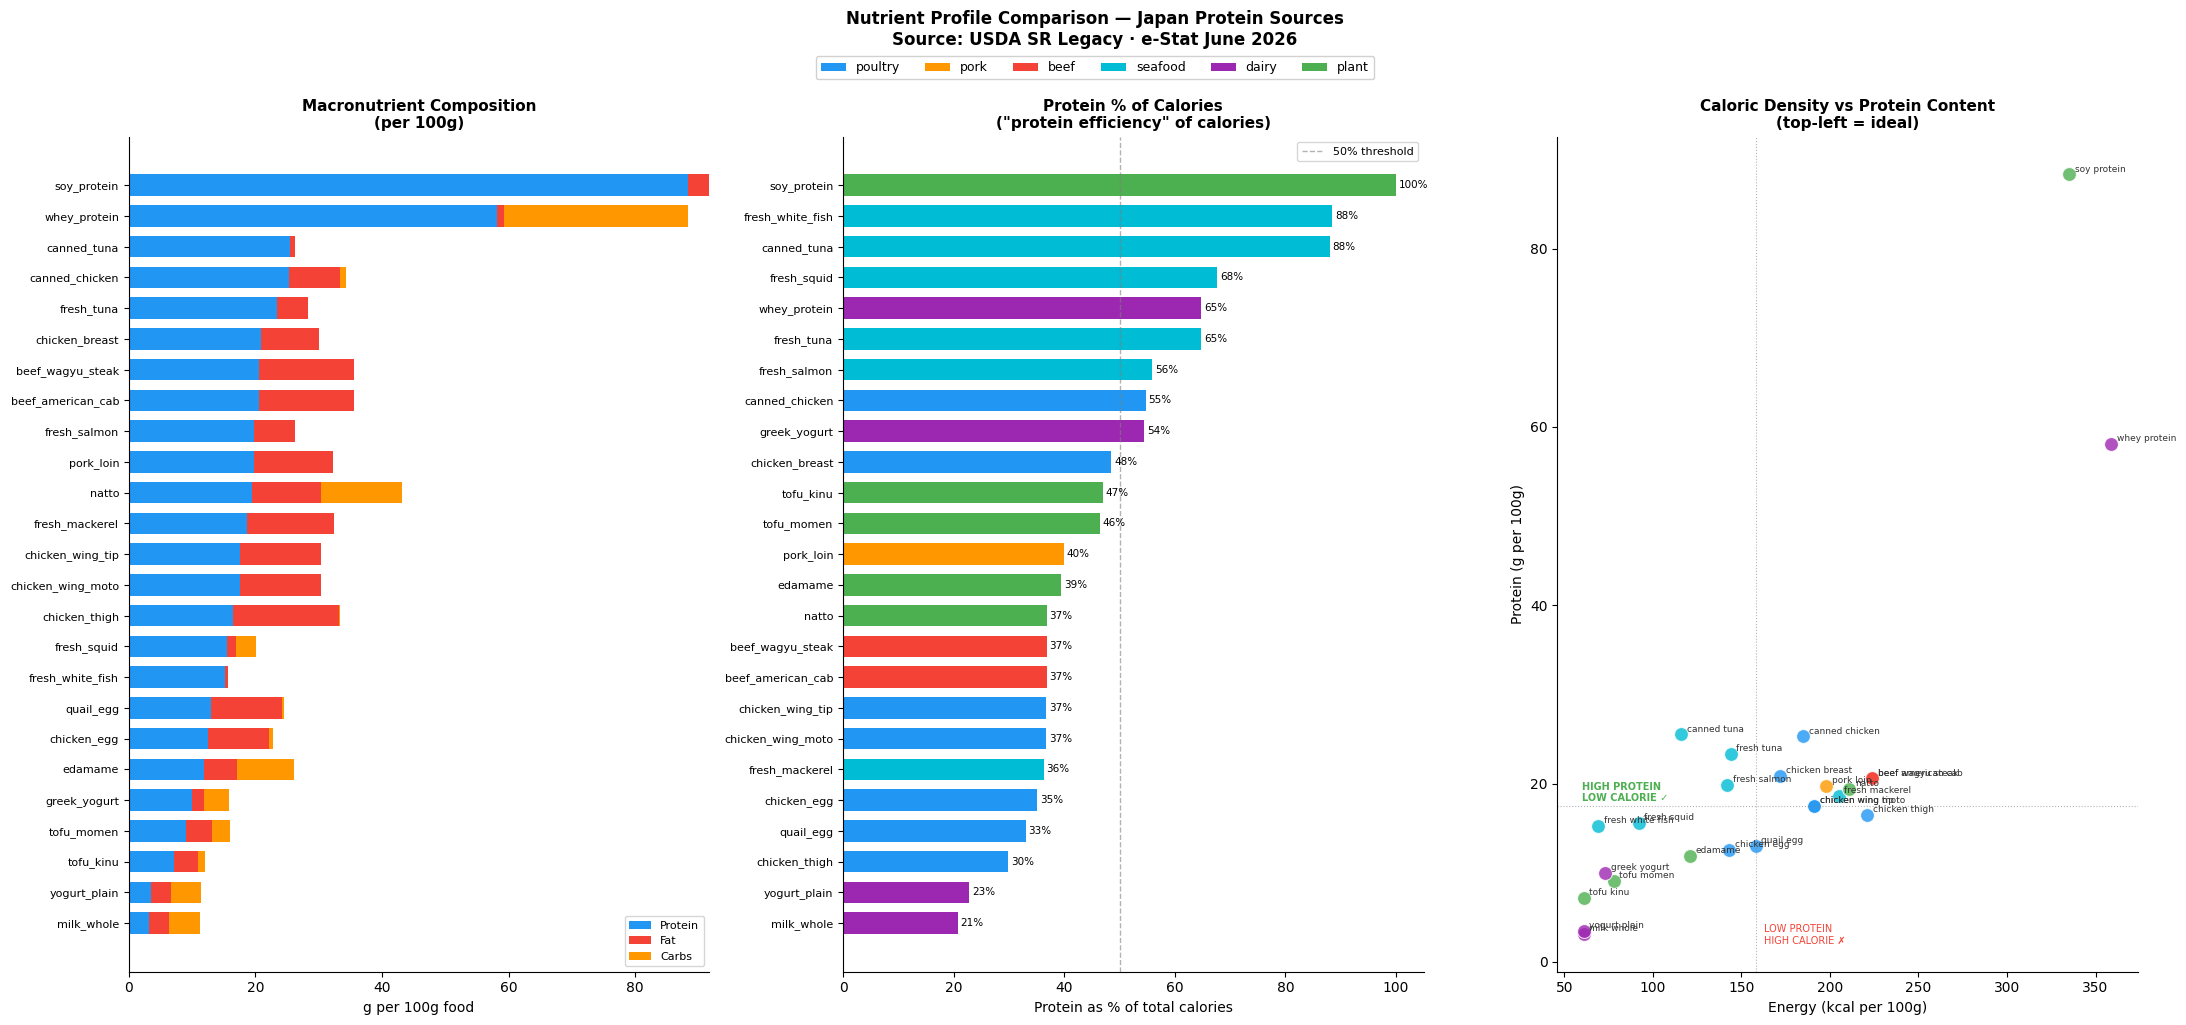

Chart saved ✓


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

df['protein_pct_kcal'] = df['protein_pct_kcal'].clip(upper=100)

# --- Panel 1: Macronutrient stacked bar ---
ax1 = axes[0]
p1 = df.sort_values('protein_g', ascending=True)
y  = np.arange(len(p1))

bars_p = ax1.barh(y, p1['protein_g'], height=0.7,
                   color='#2196F3', edgecolor='none', label='Protein')
bars_f = ax1.barh(y, p1['fat_g'], height=0.7,
                   left=p1['protein_g'],
                   color='#F44336', edgecolor='none', label='Fat')
bars_c = ax1.barh(y, p1['carbs_g'], height=0.7,
                   left=p1['protein_g'] + p1['fat_g'],
                   color='#FF9800', edgecolor='none', label='Carbs')

ax1.set_yticks(y)
ax1.set_yticklabels(p1['food_key'], fontsize=8)
ax1.set_xlabel('g per 100g food', fontsize=10)
ax1.set_title('Macronutrient Composition\n(per 100g)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.spines[['top', 'right']].set_visible(False)

# --- Panel 2: Protein % of calories ---
ax2 = axes[1]
p2 = df.sort_values('protein_pct_kcal', ascending=True)
colors2 = [CAT_COLORS[c] for c in p2['source_category']]
bars2 = ax2.barh(p2['food_key'], p2['protein_pct_kcal'],
                  color=colors2, edgecolor='none', height=0.7)

for bar, val in zip(bars2, p2['protein_pct_kcal']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}%', va='center', fontsize=7.5)

ax2.axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.6,
            label='50% threshold')
ax2.set_xlabel('Protein as % of total calories', fontsize=10)
ax2.set_title('Protein % of Calories\n("protein efficiency" of calories)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)

# --- Panel 3: Caloric density vs protein scatter ---
ax3 = axes[2]
for _, row in df.iterrows():
    color = CAT_COLORS.get(row['source_category'], 'gray')
    ax3.scatter(row['energy_kcal'], row['protein_g'],
                s=100, color=color, alpha=0.8,
                edgecolors='white', linewidths=0.8)
    ax3.annotate(
        row['food_key'].replace('_', ' '),
        xy=(row['energy_kcal'], row['protein_g']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=6.5, color='#333333'
    )

# Quadrant lines
ax3.axhline(y=df['protein_g'].median(), color='gray',
            linestyle=':', linewidth=0.8, alpha=0.6)
ax3.axvline(x=df['energy_kcal'].median(), color='gray',
            linestyle=':', linewidth=0.8, alpha=0.6)

ax3.text(60, df['protein_g'].median() + 0.5,
         'HIGH PROTEIN\nLOW CALORIE ✓',
         fontsize=7, color='#4CAF50', fontweight='bold')
ax3.text(df['energy_kcal'].median() + 5, 2,
         'LOW PROTEIN\nHIGH CALORIE ✗',
         fontsize=7, color='#F44336')

ax3.set_xlabel('Energy (kcal per 100g)', fontsize=10)
ax3.set_ylabel('Protein (g per 100g)', fontsize=10)
ax3.set_title('Caloric Density vs Protein Content\n(top-left = ideal)',
              fontsize=11, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)

# Shared category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=cat_patches, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.98))

fig.suptitle(
    'Nutrient Profile Comparison — Japan Protein Sources\n'
    'Source: USDA SR Legacy · e-Stat June 2026',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()

os.makedirs('/content/charts', exist_ok=True)
LOCAL_CHART = '/content/charts/nutrient_profile.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

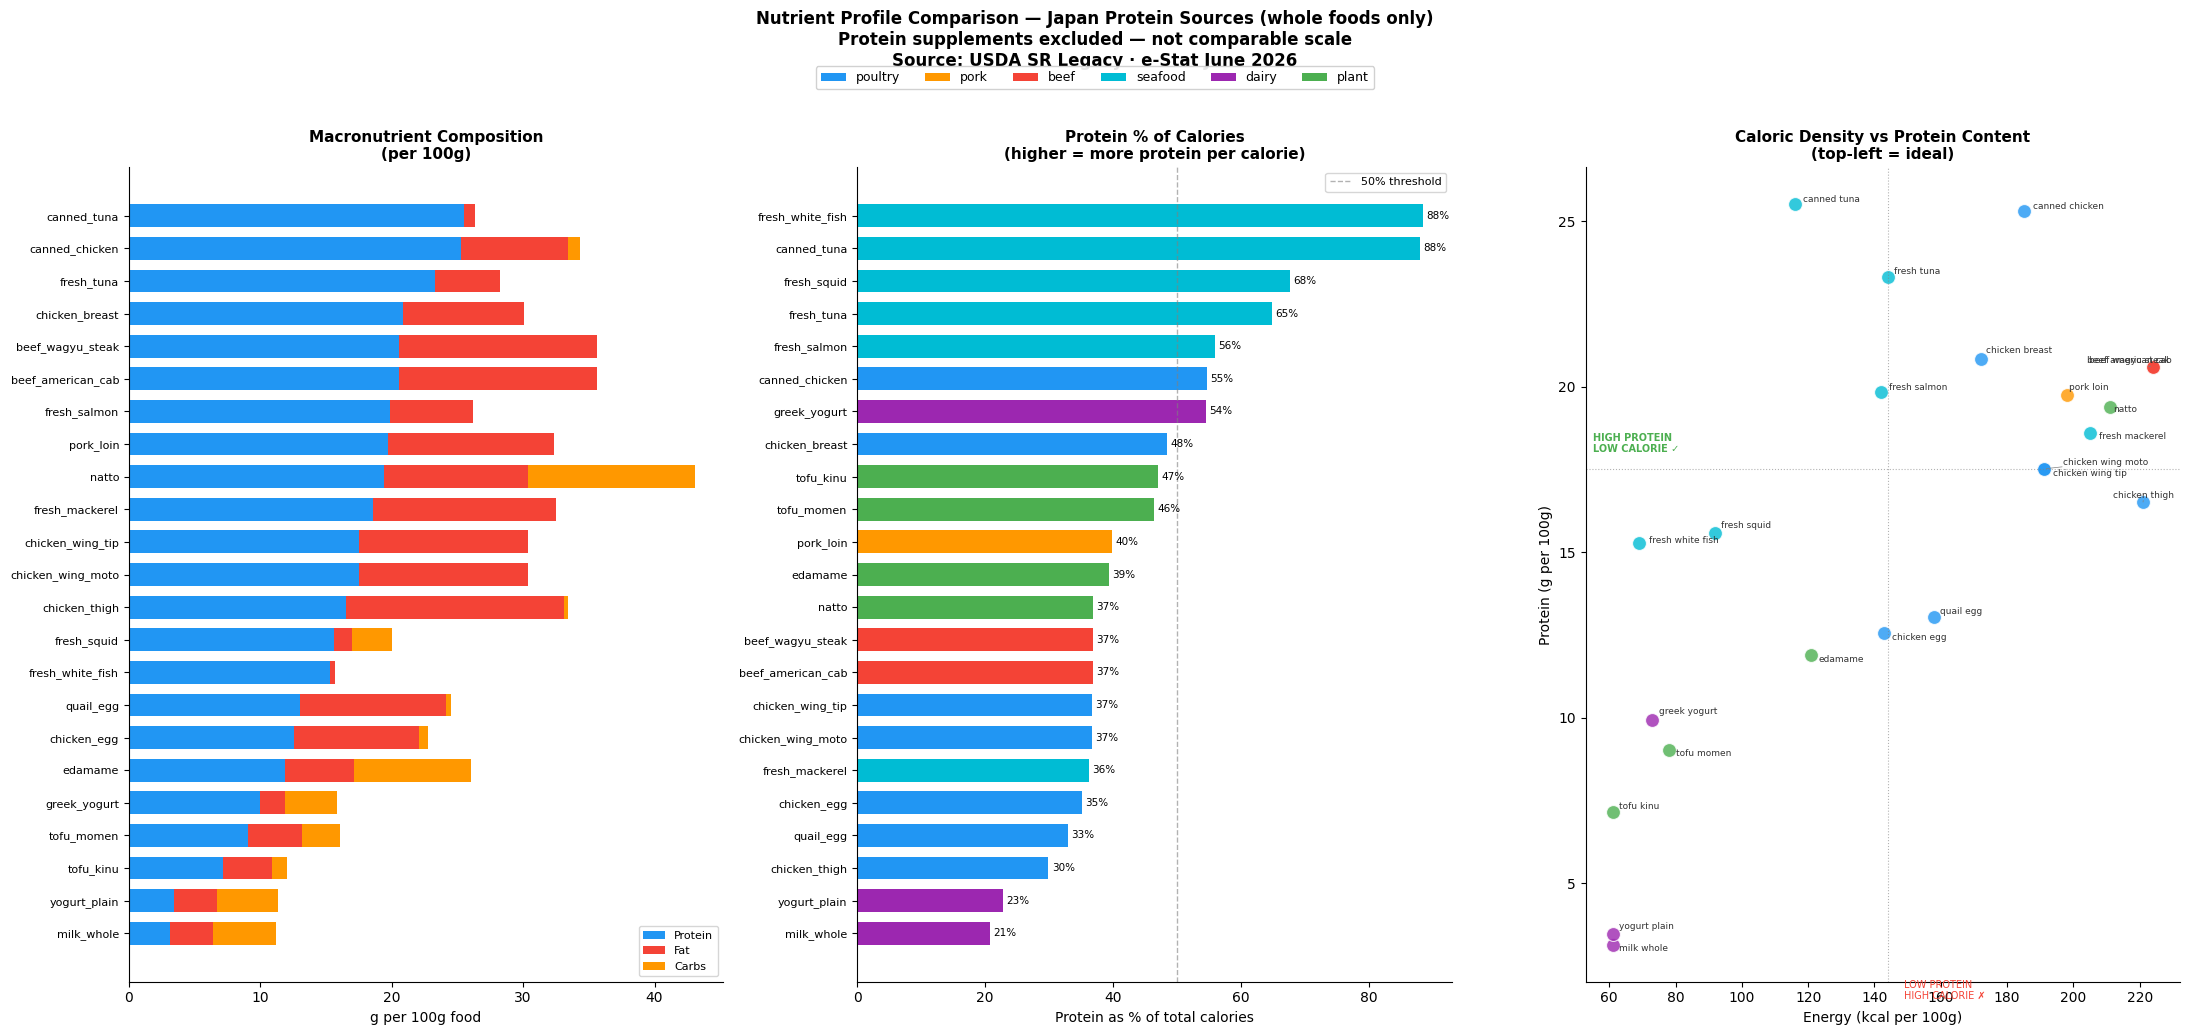

Chart saved ✓


In [ ]:
# Exclude supplements from nutrient profile — not comparable to whole foods
EXCLUDE_SUPPLEMENTS = ['whey_protein', 'soy_protein']
df_foods = df[~df['food_key'].isin(EXCLUDE_SUPPLEMENTS)].copy()

# Cap protein_pct_kcal at 100 (artifact fix)
df_foods['protein_pct_kcal'] = df_foods['protein_pct_kcal'].clip(upper=100)

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# --- Panel 1: Macronutrient stacked bar ---
ax1 = axes[0]
p1 = df_foods.sort_values('protein_g', ascending=True)
y  = np.arange(len(p1))

ax1.barh(y, p1['protein_g'], height=0.7,
         color='#2196F3', edgecolor='none', label='Protein')
ax1.barh(y, p1['fat_g'], height=0.7,
         left=p1['protein_g'],
         color='#F44336', edgecolor='none', label='Fat')
ax1.barh(y, p1['carbs_g'], height=0.7,
         left=p1['protein_g'] + p1['fat_g'],
         color='#FF9800', edgecolor='none', label='Carbs')

ax1.set_yticks(y)
ax1.set_yticklabels(p1['food_key'], fontsize=8)
ax1.set_xlabel('g per 100g food', fontsize=10)
ax1.set_title('Macronutrient Composition\n(per 100g)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.spines[['top', 'right']].set_visible(False)

# --- Panel 2: Protein % of calories ---
ax2 = axes[1]
p2 = df_foods.sort_values('protein_pct_kcal', ascending=True)
colors2 = [CAT_COLORS[c] for c in p2['source_category']]
bars2 = ax2.barh(p2['food_key'], p2['protein_pct_kcal'],
                  color=colors2, edgecolor='none', height=0.7)

for bar, val in zip(bars2, p2['protein_pct_kcal']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}%', va='center', fontsize=7.5)

ax2.axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.6,
            label='50% threshold')
ax2.set_xlabel('Protein as % of total calories', fontsize=10)
ax2.set_title('Protein % of Calories\n(higher = more protein per calorie)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)

# --- Panel 3: Caloric density vs protein scatter ---
ax3 = axes[2]
from adjustText import adjust_text

texts = []
for _, row in df_foods.iterrows():
    color = CAT_COLORS.get(row['source_category'], 'gray')
    ax3.scatter(row['energy_kcal'], row['protein_g'],
                s=100, color=color, alpha=0.8,
                edgecolors='white', linewidths=0.8)
    texts.append(ax3.text(
        row['energy_kcal'], row['protein_g'],
        row['food_key'].replace('_', ' '),
        fontsize=6.5, color='#333333'
    ))

adjust_text(texts, ax=ax3,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Quadrant lines
med_kcal    = df_foods['energy_kcal'].median()
med_protein = df_foods['protein_g'].median()
ax3.axhline(y=med_protein, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax3.axvline(x=med_kcal,    color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

ax3.text(55, med_protein + 0.5, 'HIGH PROTEIN\nLOW CALORIE ✓',
         fontsize=7, color='#4CAF50', fontweight='bold')
ax3.text(med_kcal + 5, 1.5, 'LOW PROTEIN\nHIGH CALORIE ✗',
         fontsize=7, color='#F44336')

ax3.set_xlabel('Energy (kcal per 100g)', fontsize=10)
ax3.set_ylabel('Protein (g per 100g)', fontsize=10)
ax3.set_title('Caloric Density vs Protein Content\n(top-left = ideal)',
              fontsize=11, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)

# Shared category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=cat_patches, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.98))

fig.suptitle(
    'Nutrient Profile Comparison — Japan Protein Sources (whole foods only)\n'
    'Protein supplements excluded — not comparable scale\n'
    'Source: USDA SR Legacy · e-Stat June 2026',
    fontsize=12, fontweight='bold', y=1.03
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/nutrient_profile.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# EXPORT — Notebook 04 final dataset and all charts
# ============================================================

# Save final combined table
LOCAL_CSV = '/content/nutrients_analysis.csv'
df.to_csv(LOCAL_CSV, index=False)
print(f'Saved locally: {df.shape[0]} rows × {df.shape[1]} columns')

# Files to upload
upload_files = [
    ('nutrients_analysis.csv',          LOCAL_CSV,                                    'text/csv'),
    ('category_analysis.png',           '/content/charts/category_analysis.png',      'image/png'),
    ('quality_vs_cost_scatter.png',     '/content/charts/quality_vs_cost_scatter.png','image/png'),
    ('sensitivity_analysis.png',        '/content/charts/sensitivity_analysis.png',   'image/png'),
    ('smart_shopper_heatmap.png',       '/content/charts/smart_shopper_heatmap.png',  'image/png'),
    ('muscle_smart_shopper_heatmap.png','/content/charts/muscle_smart_shopper_heatmap.png','image/png'),
    ('nutrient_profile.png',            '/content/charts/nutrient_profile.png',       'image/png'),
]

for filename, local_path, mimetype in upload_files:
    if not os.path.exists(local_path):
        print(f'⚠️  {filename} not found — skipping')
        continue
    # Delete existing
    existing = service.files().list(
        q=f"name='{filename}' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
        fields="files(id, name)"
    ).execute()
    for f in existing['files']:
        service.files().delete(fileId=f['id']).execute()

    media    = MediaFileUpload(local_path, mimetype=mimetype)
    meta     = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    uploaded = service.files().create(body=meta, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {uploaded["name"]}')

print('\nAll files uploaded ✓')

Saved locally: 25 rows × 19 columns
✓ Uploaded nutrients_analysis.csv
✓ Uploaded category_analysis.png
✓ Uploaded quality_vs_cost_scatter.png
✓ Uploaded sensitivity_analysis.png
✓ Uploaded smart_shopper_heatmap.png
✓ Uploaded muscle_smart_shopper_heatmap.png
✓ Uploaded nutrient_profile.png

All files uploaded ✓


In [ ]:
# Export smart shopper tables to Drive
smart_shopper['current_price_per_100g'] = smart_shopper['current_price_per_100g']

for filename, dataframe in [
    ('tableau_smart_shopper.csv', smart_shopper),
    ('tableau_muscle_smart_shopper.csv', muscle_ss),
]:
    local_path = f'/content/{filename}'
    dataframe.to_csv(local_path, index=False)

    existing = service.files().list(
        q=f"name='{filename}' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
        fields="files(id, name)"
    ).execute()
    for f in existing['files']:
        service.files().delete(fileId=f['id']).execute()

    media    = MediaFileUpload(local_path, mimetype='text/csv')
    meta     = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    uploaded = service.files().create(body=meta, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {uploaded["name"]}')

✓ Uploaded tableau_smart_shopper.csv
✓ Uploaded tableau_muscle_smart_shopper.csv


## Summary & Next Steps

### What this notebook produced

**Part A — Deeper Analysis**
- Category-level comparison with best performer per category
- Protein quality vs cost scatter — identifying over/undervalued foods
- Sensitivity analysis — rank changes as individual food prices vary ±30%
- Nutrient profile comparison — macronutrients, protein % of calories, caloric density

**Part B — Smart Shopper Tool**
- General Smart Shopper heatmap — break-even price thresholds vs 3 benchmarks
- Muscle Smart Shopper heatmap — same tool using muscle cost efficiency score
  (Leucine×0.70 + DIAAS×0.30), with sensitivity analysis confirming robustness

### Key findings

- **Chicken egg is the most cost-efficient complete protein overall** — consistent across all weight combinations
- **Natto is the best budget leucine source** but SAA-limited and borderline incomplete
- **Milk whole ranks #1 on muscle cost efficiency** — cheap DIAAS-adjusted value, but low absolute leucine requires large serving sizes
- **Plant proteins dominate low price points** but are penalized by DIAAS and amino acid completeness
- **Wagyu and fresh salmon are never good value** regardless of metric or discount level
- **Protein supplements rank mid-table** — not the most cost-efficient whole-food replacement

### Data outputs
- `nutrients_analysis.csv` — 25-food consolidated dataset with all metrics
- 6 charts saved to Drive

### Limitations
- Pork, beef, and chicken sasami consolidated to representative entries — cut-level variation not captured
- Greek yogurt AA data flagged as potentially underreported — excluded from amino acid recommendations
- Muscle composite weights (Leu 70% / DIAAS 30%) are literature-informed but not universally agreed upon
- Sensitivity analysis confirms top 4 foods are robust — lower ranked foods more sensitive to weight choice

### Next steps
- **Notebook 05** — shape final clean dataset for Tableau export
